Simulating for Fractal Dimension: 1.10...


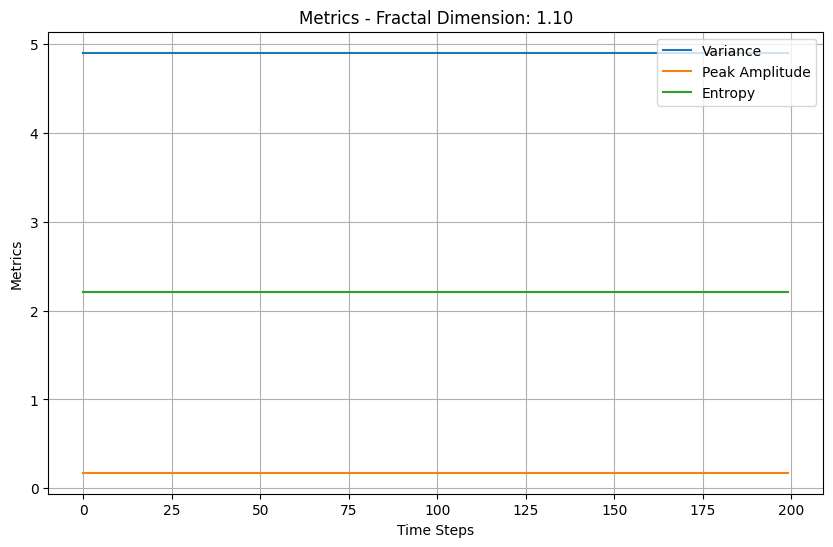

Simulating for Fractal Dimension: 1.50...


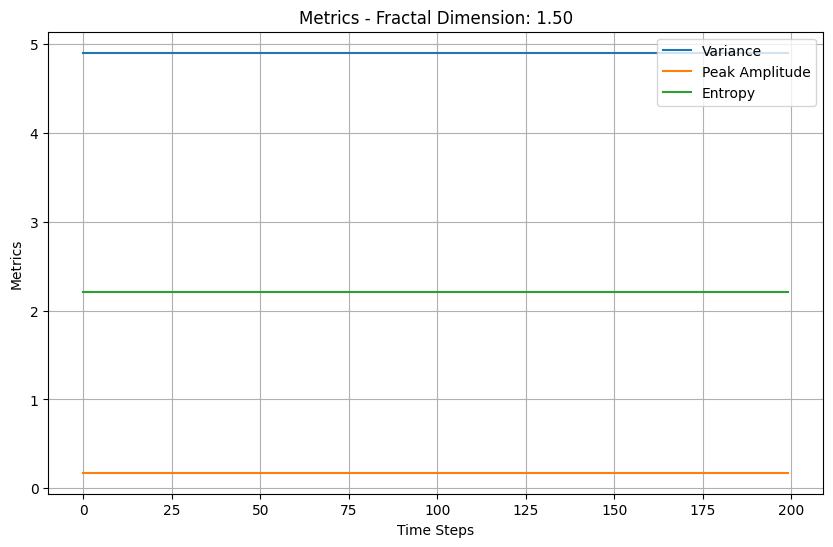

Simulating for Fractal Dimension: 2.00...


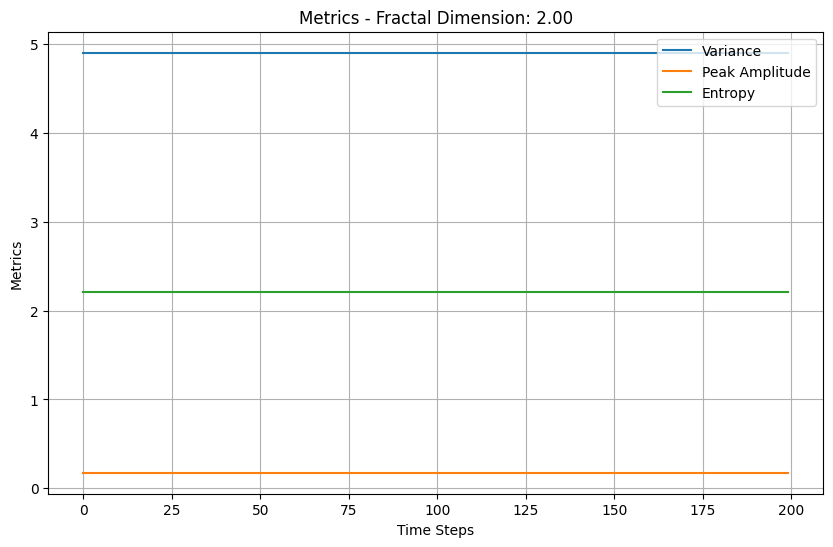

Simulating for Fractal Dimension: 2.50...


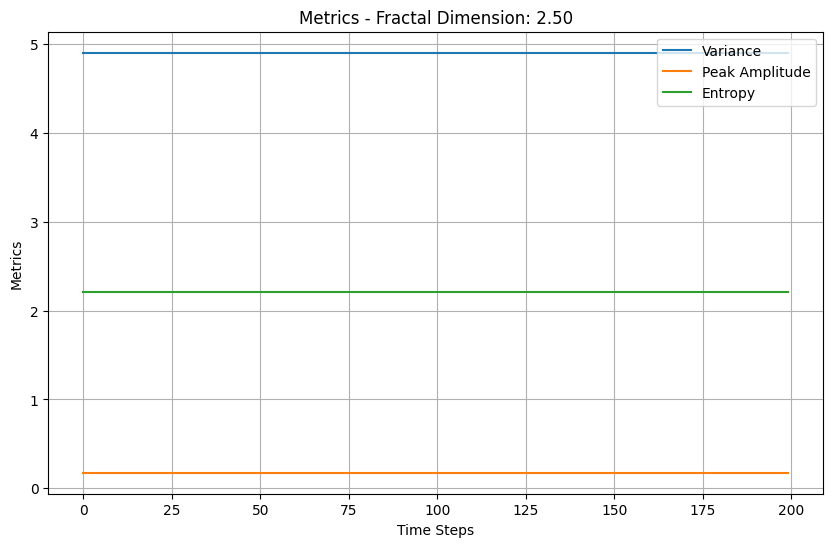

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.linalg import expm

# Constants
GRID_SIZE = 100  # Size of the 1D grid
TIME_STEPS = 200  # Number of time steps
DELTA_X = 1.0  # Spatial resolution
DELTA_T = 0.01  # Time step
H_BAR = 1.0  # Reduced Planck's constant
MASS = 1.0  # Mass of the particle
FRACTAL_DIMENSIONS = [1.1, 1.5, 2.0, 2.5]  # Test fractal dimensions
V0 = 0.0  # Flat potential for now

# Fractal Laplacian
def fractal_laplacian(grid_size, fractal_dimension):
    diagonal = np.ones(grid_size)
    off_diagonal = np.ones(grid_size - 1)
    laplacian = diags([diagonal, -2 * diagonal, diagonal], [0, -1, 1]).toarray()

    # Fractal scaling: power-law weights for Laplacian
    fractal_weights = np.abs(np.linspace(-grid_size // 2, grid_size // 2, grid_size)) ** (-fractal_dimension)
    fractal_weights /= np.max(fractal_weights)  # Normalize weights
    laplacian *= np.diag(fractal_weights)

    return laplacian / (DELTA_X**2)

# Initialize wavefunction
def initialize_wavefunction(grid_size):
    x = np.linspace(-grid_size // 2, grid_size // 2, grid_size)
    psi = np.exp(-(x**2) / 20.0) * np.exp(1j * 2.0 * np.pi * x / grid_size)
    return psi / np.linalg.norm(psi)

# Time evolution of the wavefunction
def evolve_wavefunction(psi, laplacian, time_steps, delta_t, potential=None):
    # Hamiltonian: T (kinetic) + V (potential)
    hamiltonian = -H_BAR**2 / (2 * MASS) * laplacian
    if potential is not None:
        hamiltonian += np.diag(potential)
    evolution_operator = expm(-1j * hamiltonian * delta_t / H_BAR)
    psi_t = []

    for _ in range(time_steps):
        psi = evolution_operator @ psi
        psi_t.append(np.abs(psi)**2)

    return np.array(psi_t)

# Calculate quantitative metrics
def calculate_metrics(psi_t):
    variances = []
    peak_amplitudes = []
    entropies = []

    for prob_density in psi_t:
        # Variance
        x = np.arange(len(prob_density))
        mean = np.sum(x * prob_density)
        variance = np.sum(((x - mean) ** 2) * prob_density)
        variances.append(variance)

        # Peak amplitude
        peak_amplitude = np.max(prob_density)
        peak_amplitudes.append(peak_amplitude)

        # Shannon entropy
        entropy = -np.sum(prob_density * np.log(prob_density + 1e-12))
        entropies.append(entropy)

    return variances, peak_amplitudes, entropies

# Plot metrics
def plot_metrics(metrics, fractal_dimension, metric_name):
    plt.figure(figsize=(10, 6))
    for metric, label in zip(metrics, ["Variance", "Peak Amplitude", "Entropy"]):
        plt.plot(metric, label=label)
    plt.title(f"{metric_name} - Fractal Dimension: {fractal_dimension:.2f}")
    plt.xlabel("Time Steps")
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid()
    plt.show()

# Main experiment
def main():
    for fractal_dimension in FRACTAL_DIMENSIONS:
        print(f"Simulating for Fractal Dimension: {fractal_dimension:.2f}...")
        laplacian = fractal_laplacian(GRID_SIZE, fractal_dimension)
        psi = initialize_wavefunction(GRID_SIZE)
        psi_t = evolve_wavefunction(psi, laplacian, TIME_STEPS, DELTA_T)

        # Calculate metrics
        variances, peak_amplitudes, entropies = calculate_metrics(psi_t)

        # Plot individual results
        plot_metrics(
            [variances, peak_amplitudes, entropies],
            fractal_dimension,
            "Metrics"
        )

if __name__ == "__main__":
    main()

Simulating for Fractal Dimension: 1.10...


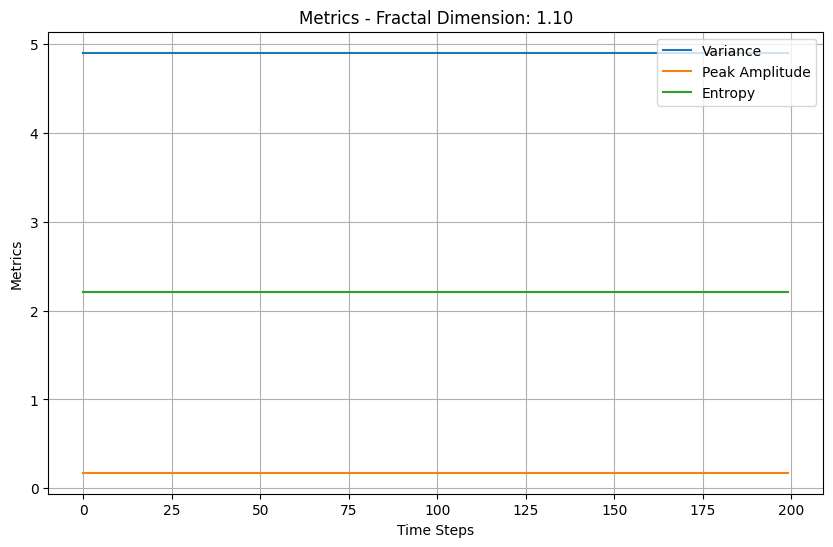

Simulating for Fractal Dimension: 1.50...


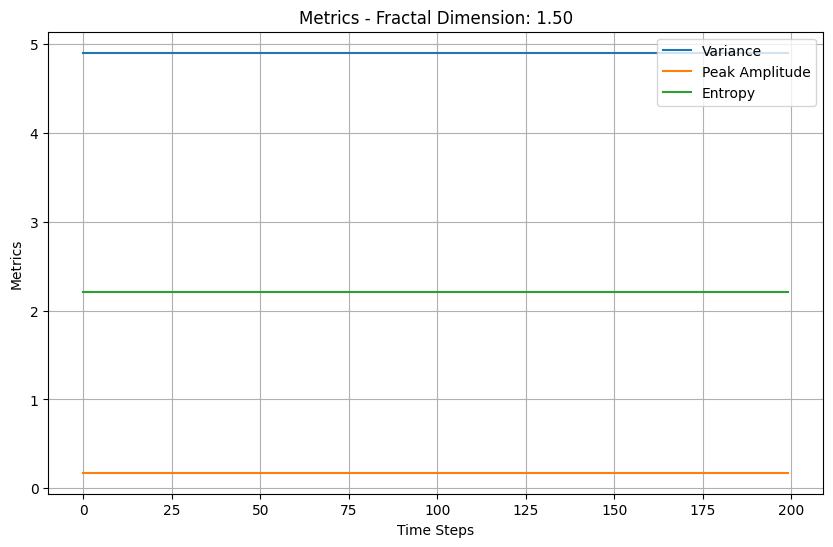

Simulating for Fractal Dimension: 2.00...


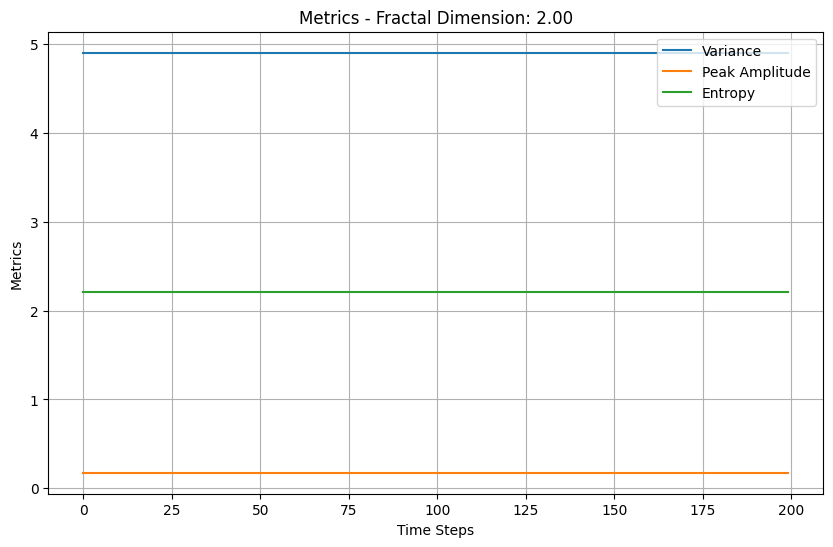

Simulating for Fractal Dimension: 2.50...


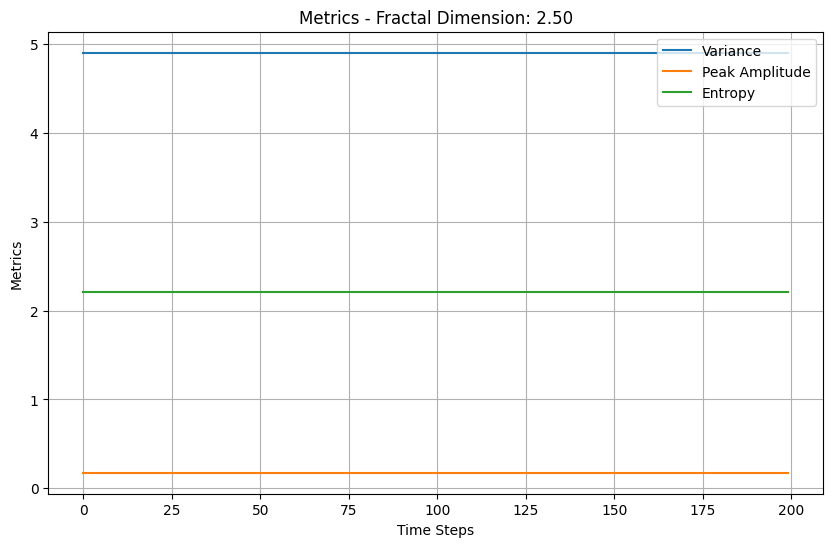

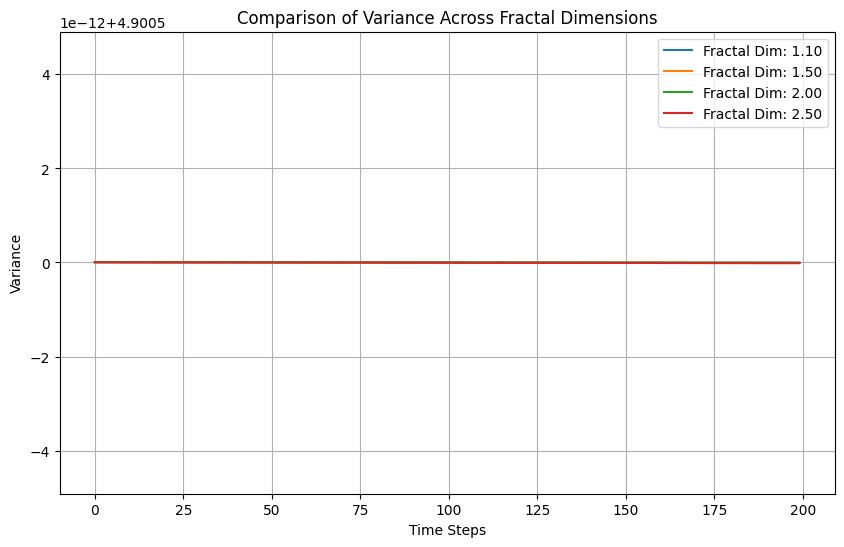

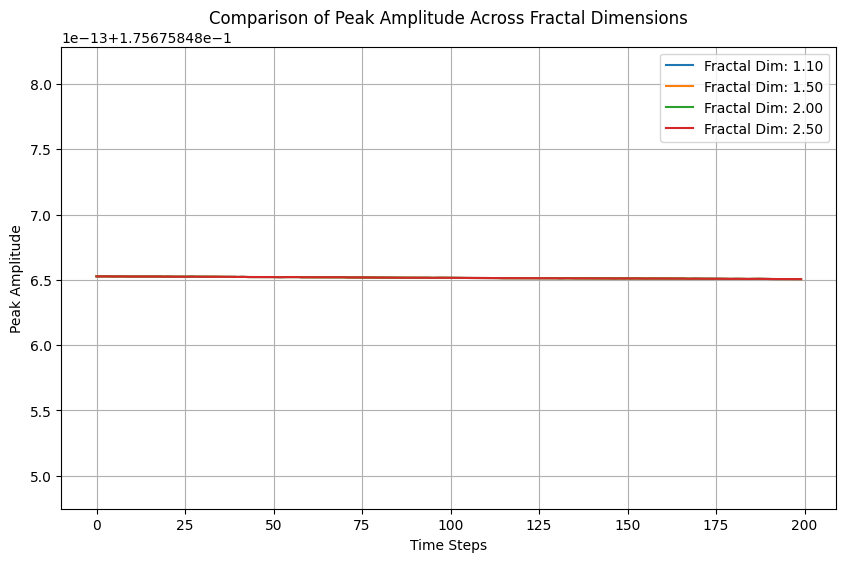

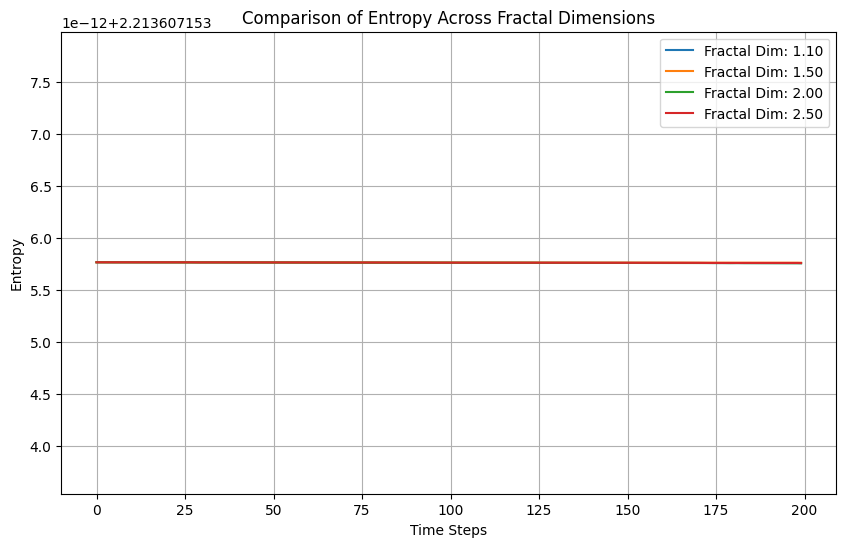

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.linalg import expm

# Constants
GRID_SIZE = 100  # Size of the 1D grid
TIME_STEPS = 200  # Number of time steps
DELTA_X = 1.0  # Spatial resolution
DELTA_T = 0.01  # Time step
H_BAR = 1.0  # Reduced Planck's constant
MASS = 1.0  # Mass of the particle
SPRING_CONSTANT = 0.1  # Spring constant for harmonic potential
FRACTAL_DIMENSIONS = [1.1, 1.5, 2.0, 2.5]  # Fractal dimensions to test

# Fractal Laplacian
def fractal_laplacian(grid_size, fractal_dimension):
    diagonal = np.ones(grid_size)
    off_diagonal = np.ones(grid_size - 1)
    laplacian = diags([diagonal, -2 * diagonal, diagonal], [0, -1, 1]).toarray()

    # Fractal scaling: power-law weights for Laplacian
    fractal_weights = np.abs(np.linspace(-grid_size // 2, grid_size // 2, grid_size)) ** (-fractal_dimension)
    fractal_weights /= np.max(fractal_weights)  # Normalize weights
    laplacian *= np.diag(fractal_weights)

    return laplacian / (DELTA_X**2)

# Harmonic potential
def harmonic_potential(grid_size, spring_constant):
    x = np.linspace(-grid_size // 2, grid_size // 2, grid_size)
    return 0.5 * spring_constant * x**2

# Initialize wavefunction
def initialize_wavefunction(grid_size):
    x = np.linspace(-grid_size // 2, grid_size // 2, grid_size)
    psi = np.exp(-(x**2) / 20.0) * np.exp(1j * 2.0 * np.pi * x / grid_size)
    return psi / np.linalg.norm(psi)

# Time evolution of the wavefunction
def evolve_wavefunction(psi, laplacian, time_steps, delta_t, potential=None):
    # Hamiltonian: T (kinetic) + V (potential)
    hamiltonian = -H_BAR**2 / (2 * MASS) * laplacian
    if potential is not None:
        hamiltonian += np.diag(potential)
    evolution_operator = expm(-1j * hamiltonian * delta_t / H_BAR)
    psi_t = []

    for _ in range(time_steps):
        psi = evolution_operator @ psi
        psi_t.append(np.abs(psi)**2)

    return np.array(psi_t)

# Calculate quantitative metrics
def calculate_metrics(psi_t):
    variances = []
    peak_amplitudes = []
    entropies = []

    for prob_density in psi_t:
        # Variance
        x = np.arange(len(prob_density))
        mean = np.sum(x * prob_density)
        variance = np.sum(((x - mean) ** 2) * prob_density)
        variances.append(variance)

        # Peak amplitude
        peak_amplitude = np.max(prob_density)
        peak_amplitudes.append(peak_amplitude)

        # Shannon entropy
        entropy = -np.sum(prob_density * np.log(prob_density + 1e-12))
        entropies.append(entropy)

    return variances, peak_amplitudes, entropies

# Plot metrics for a specific fractal dimension
def plot_results(metrics, fractal_dimension, metric_name):
    plt.figure(figsize=(10, 6))
    for metric, label in zip(metrics, ["Variance", "Peak Amplitude", "Entropy"]):
        plt.plot(metric, label=label)
    plt.title(f"{metric_name} - Fractal Dimension: {fractal_dimension:.2f}")
    plt.xlabel("Time Steps")
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid()
    plt.show()

# Compare metrics across all fractal dimensions
def compare_metrics(metrics_by_dimension, metric_name):
    plt.figure(figsize=(10, 6))
    for d_f, metrics in metrics_by_dimension.items():
        plt.plot(metrics, label=f"Fractal Dim: {d_f:.2f}")
    plt.title(f"Comparison of {metric_name} Across Fractal Dimensions")
    plt.xlabel("Time Steps")
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid()
    plt.show()

# Main experiment
def main():
    metrics_by_dimension = {
        "Variance": {},
        "Peak Amplitude": {},
        "Entropy": {}
    }

    for fractal_dimension in FRACTAL_DIMENSIONS:
        print(f"Simulating for Fractal Dimension: {fractal_dimension:.2f}...")
        laplacian = fractal_laplacian(GRID_SIZE, fractal_dimension)
        potential = harmonic_potential(GRID_SIZE, SPRING_CONSTANT)
        psi = initialize_wavefunction(GRID_SIZE)
        psi_t = evolve_wavefunction(psi, laplacian, TIME_STEPS, DELTA_T, potential=potential)

        # Calculate metrics
        variances, peak_amplitudes, entropies = calculate_metrics(psi_t)
        metrics_by_dimension["Variance"][fractal_dimension] = variances
        metrics_by_dimension["Peak Amplitude"][fractal_dimension] = peak_amplitudes
        metrics_by_dimension["Entropy"][fractal_dimension] = entropies

        # Plot individual results
        plot_results(
            [variances, peak_amplitudes, entropies],
            fractal_dimension,
            "Metrics"
        )

    # Compare metrics across dimensions
    for metric_name in ["Variance", "Peak Amplitude", "Entropy"]:
        compare_metrics(
            {d_f: metrics_by_dimension[metric_name][d_f] for d_f in FRACTAL_DIMENSIONS},
            metric_name
        )

if __name__ == "__main__":
    main()

Simulating for Fractal Dimension: 1.10...


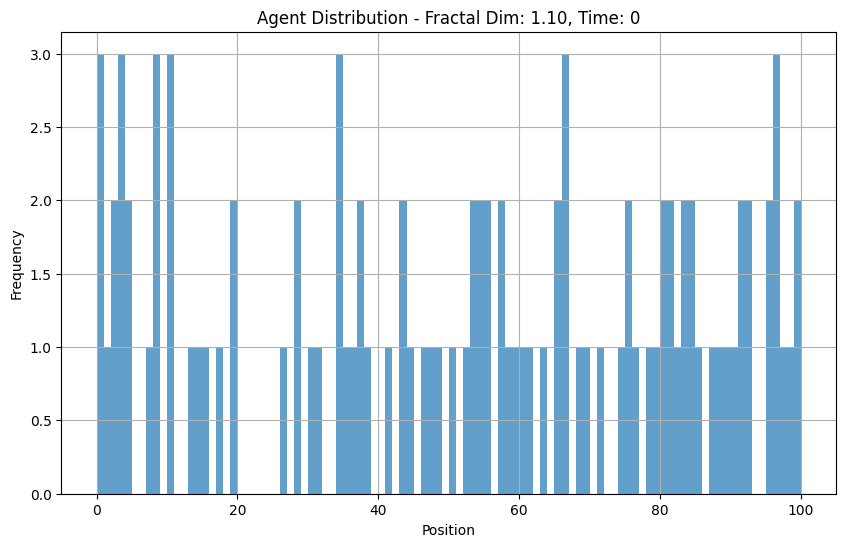

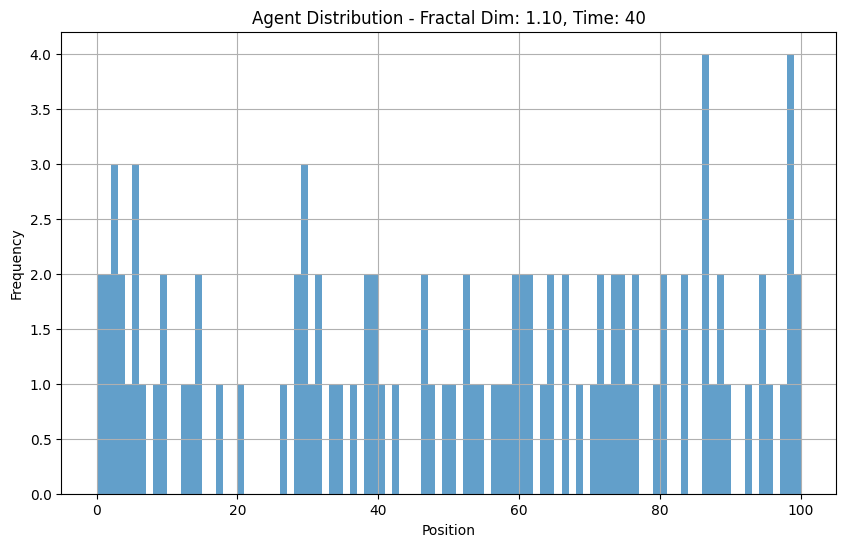

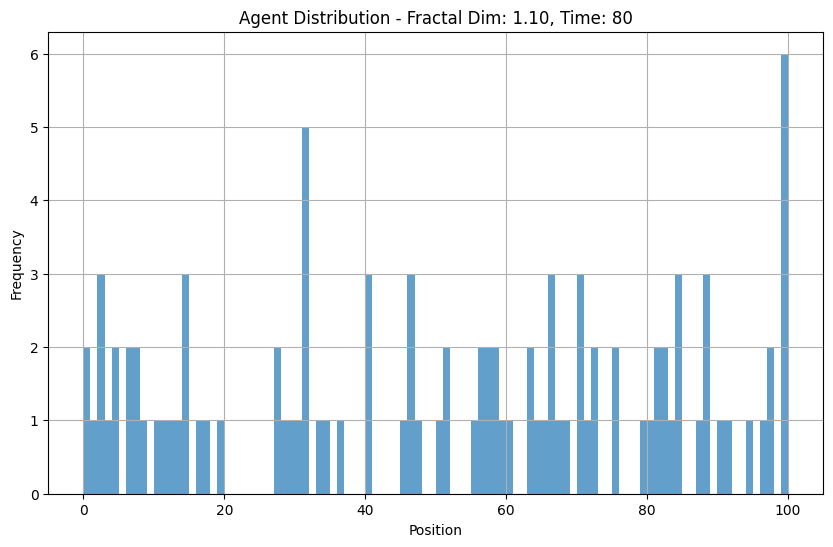

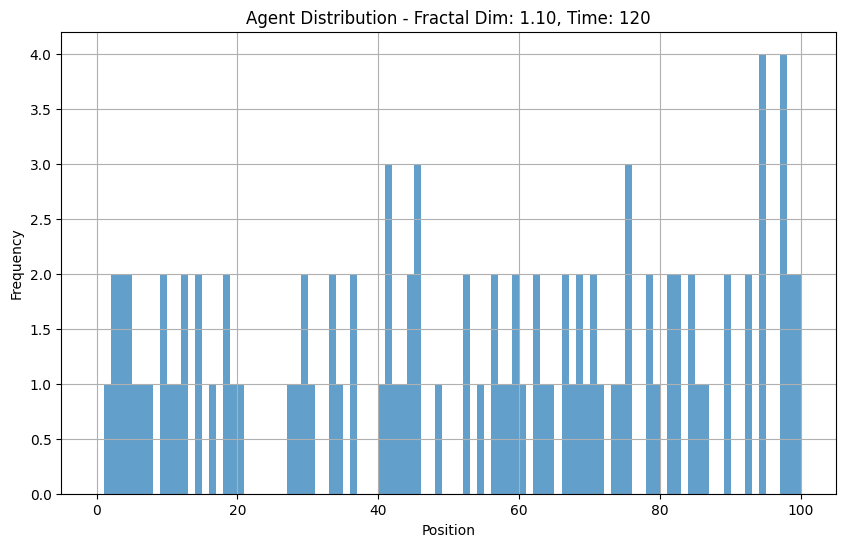

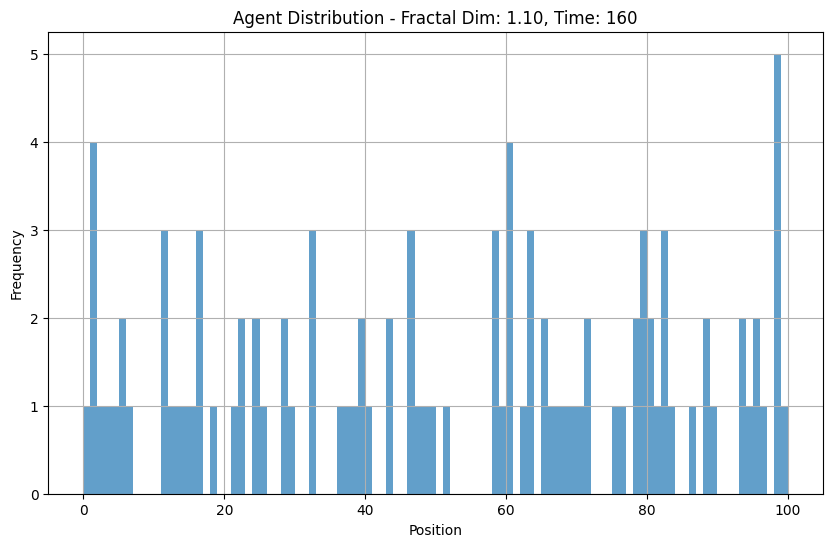

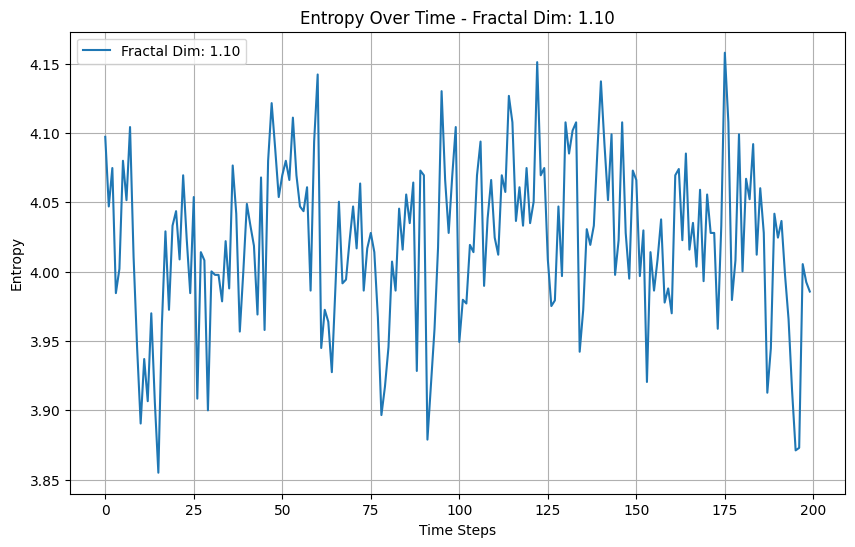

Simulating for Fractal Dimension: 1.50...


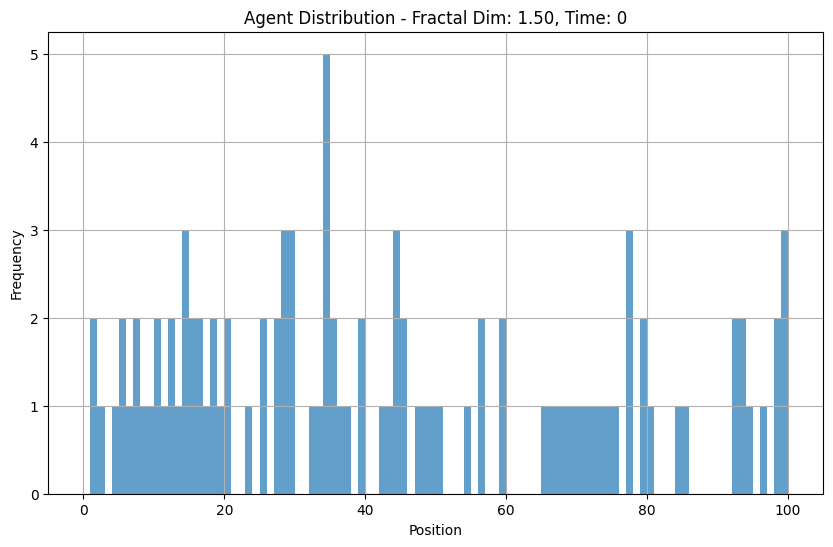

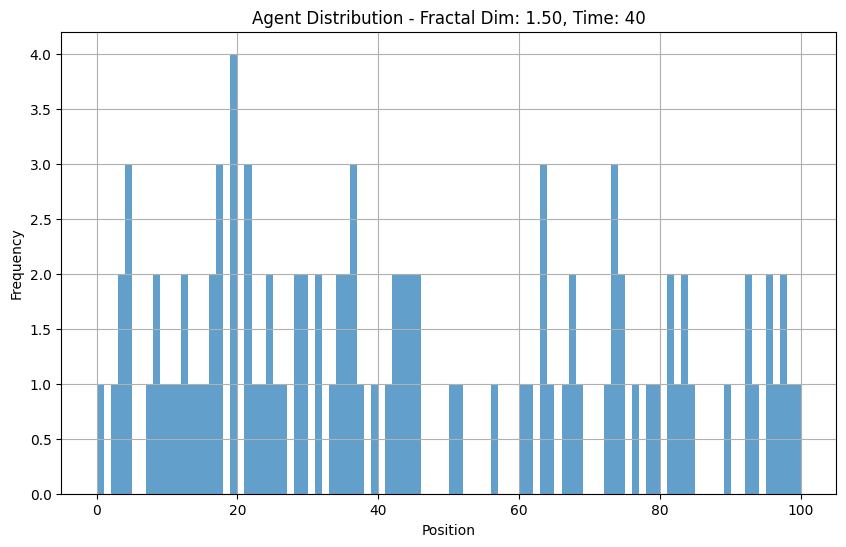

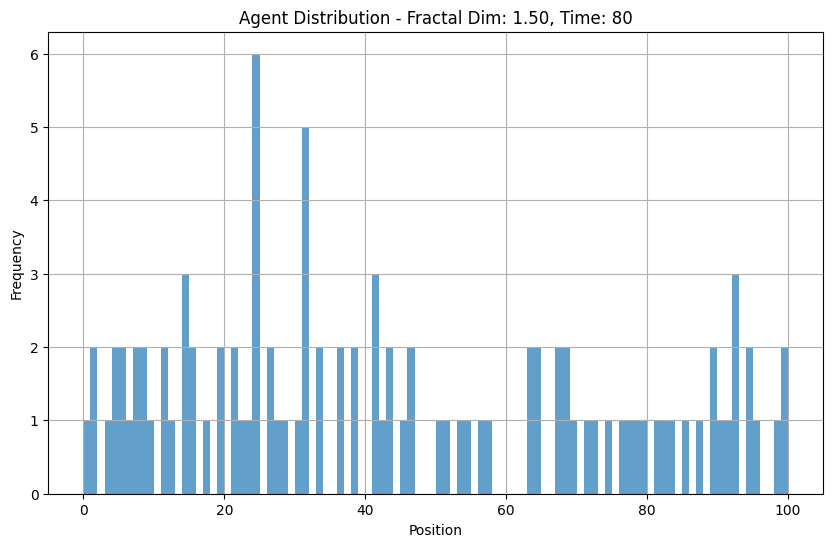

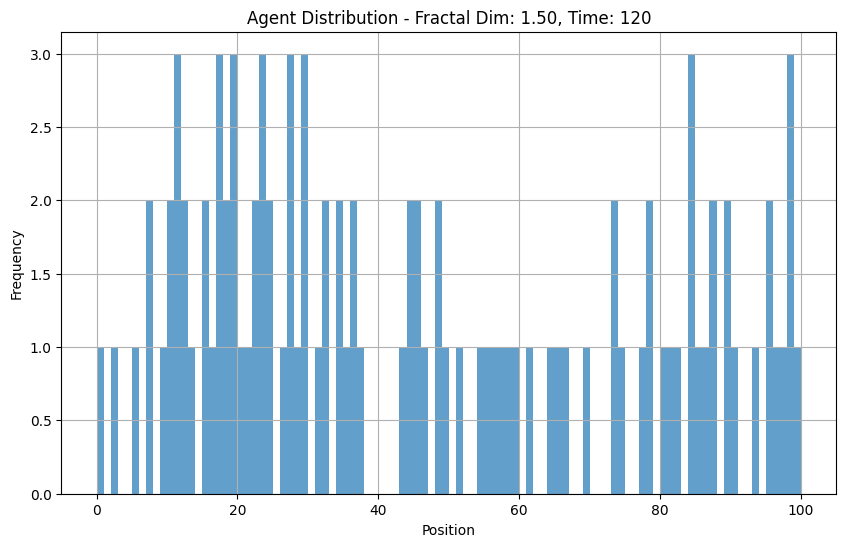

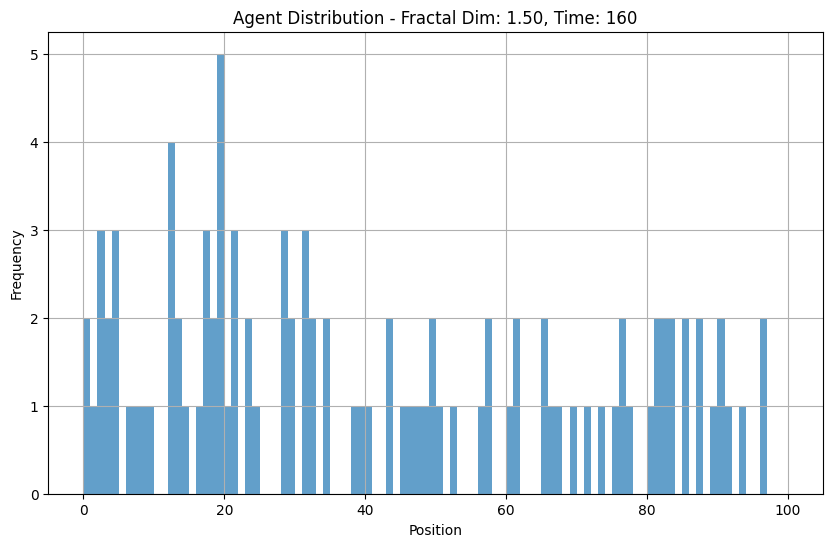

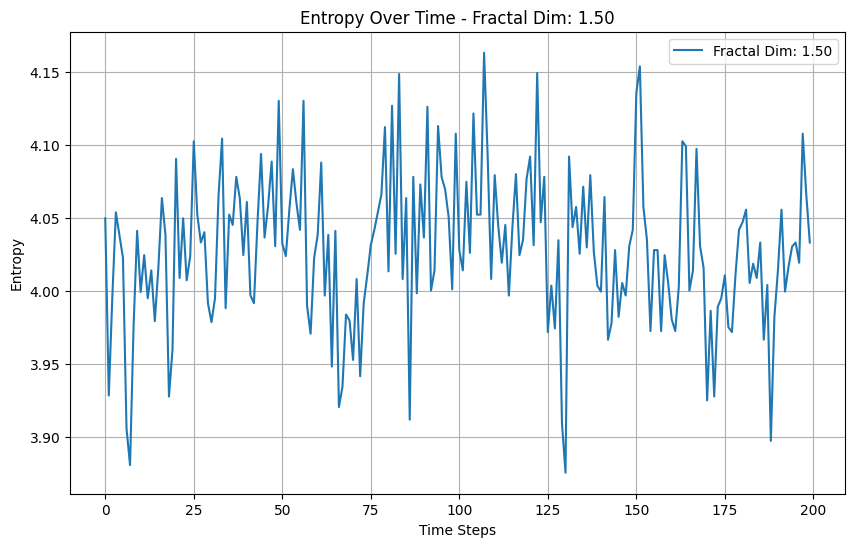

Simulating for Fractal Dimension: 2.00...


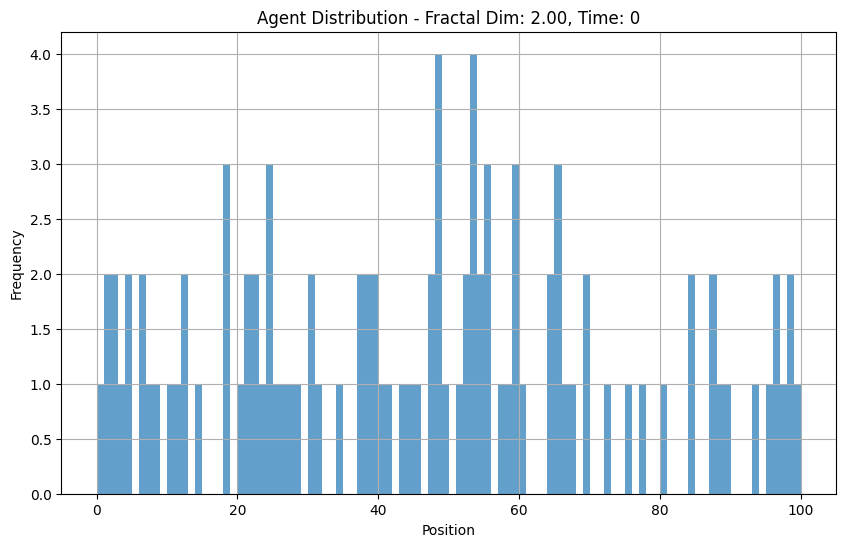

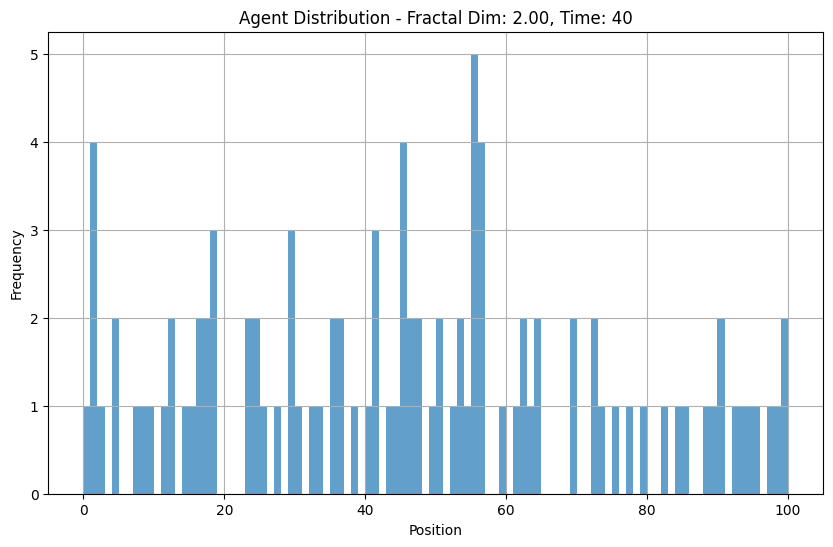

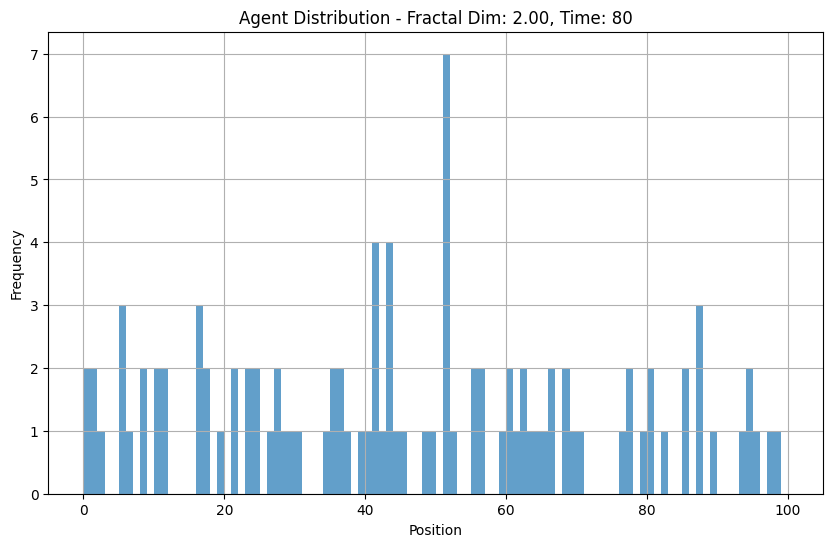

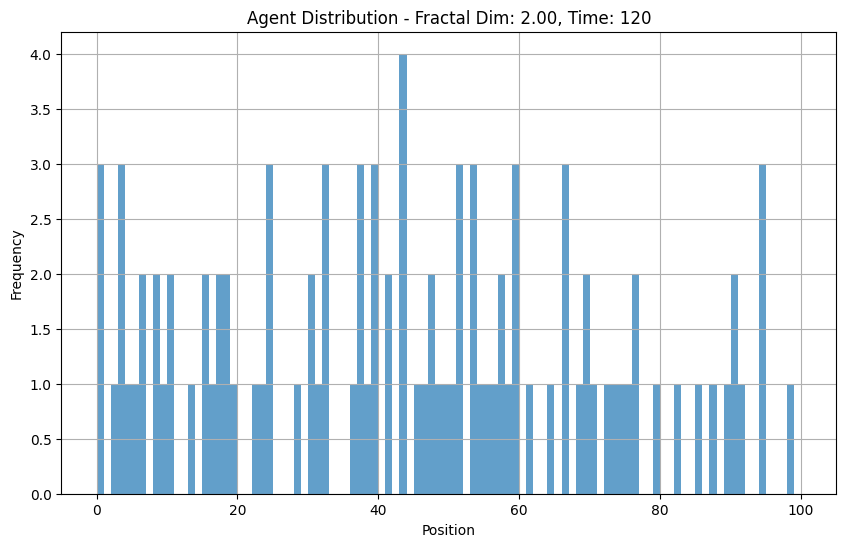

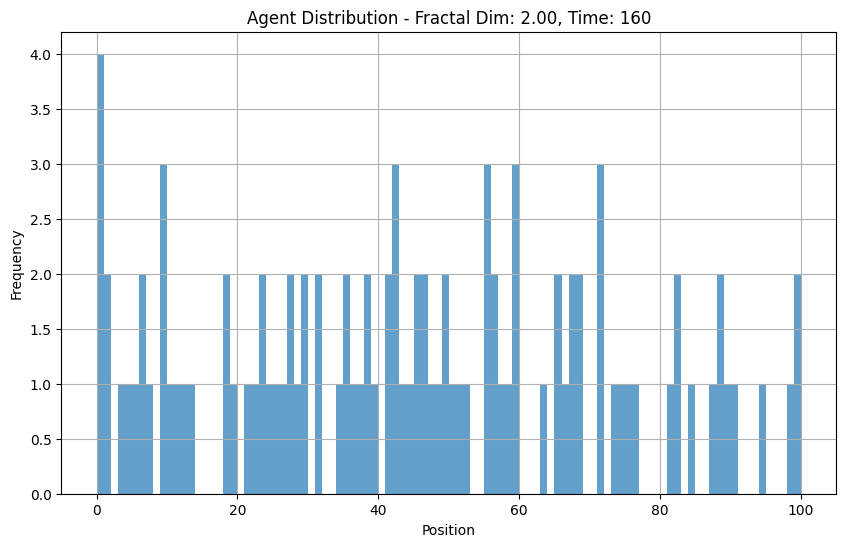

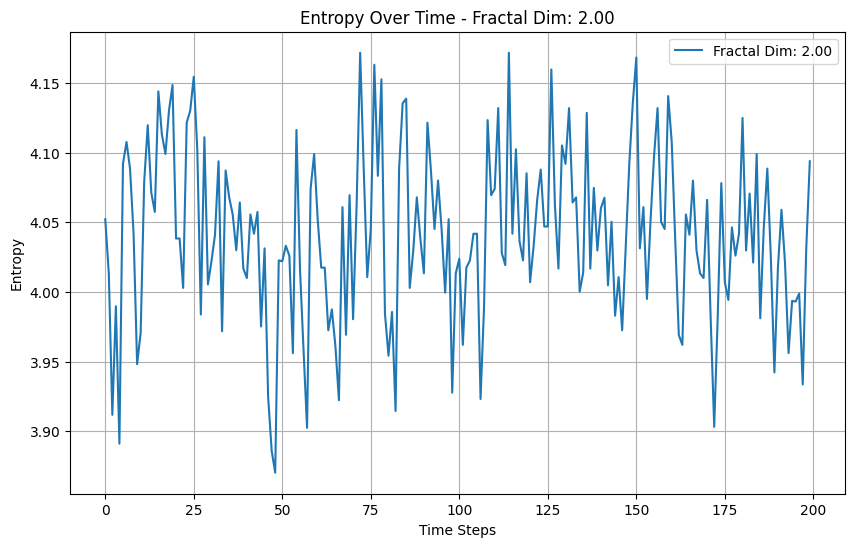

Simulating for Fractal Dimension: 2.50...


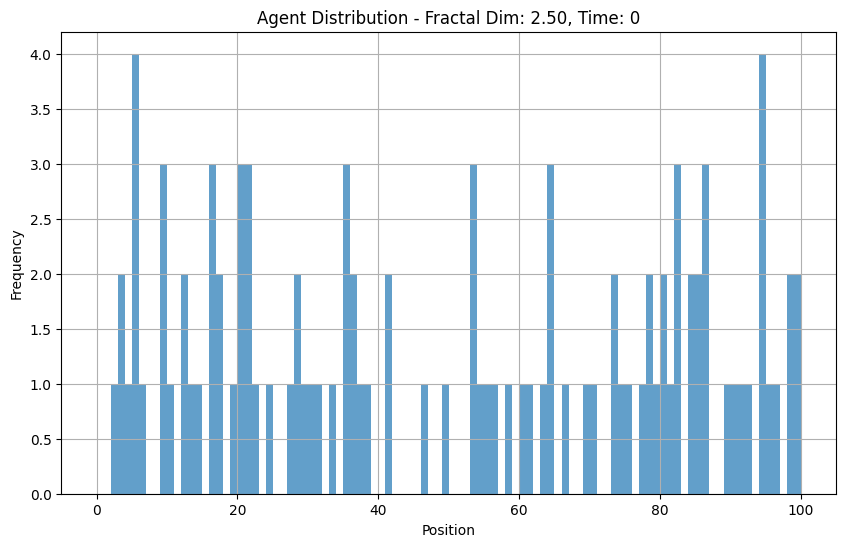

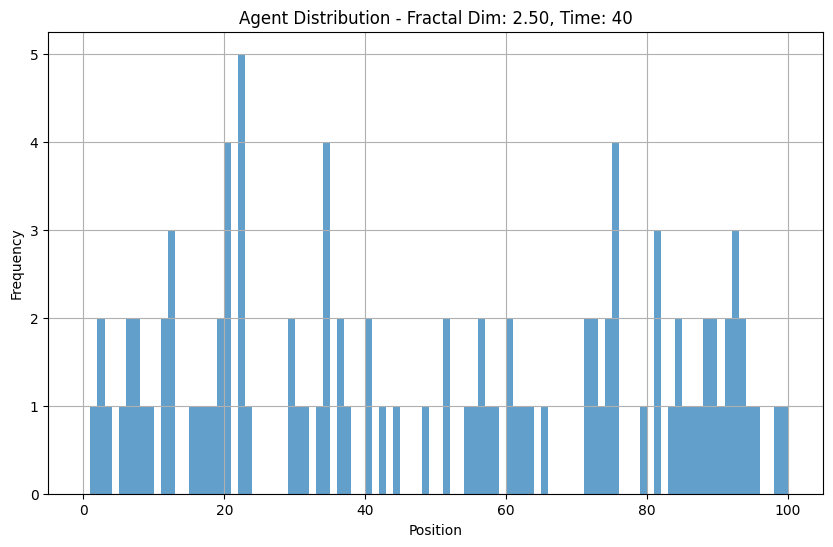

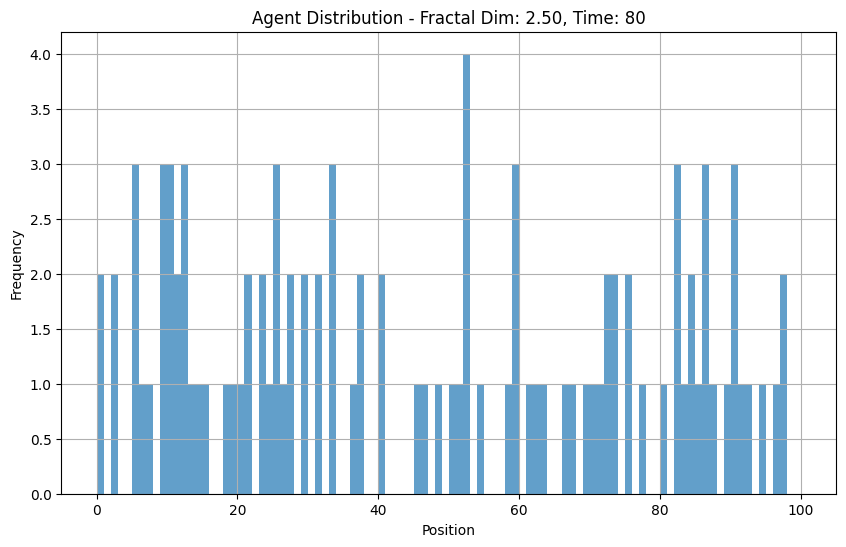

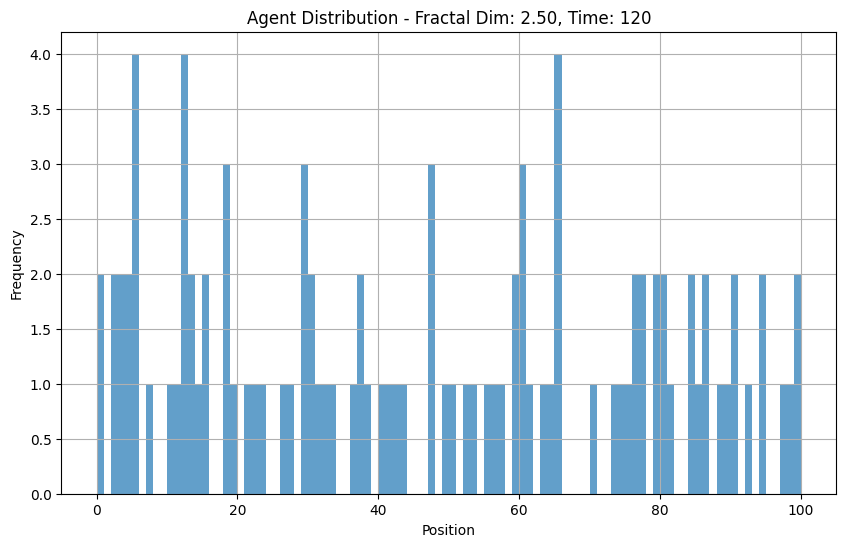

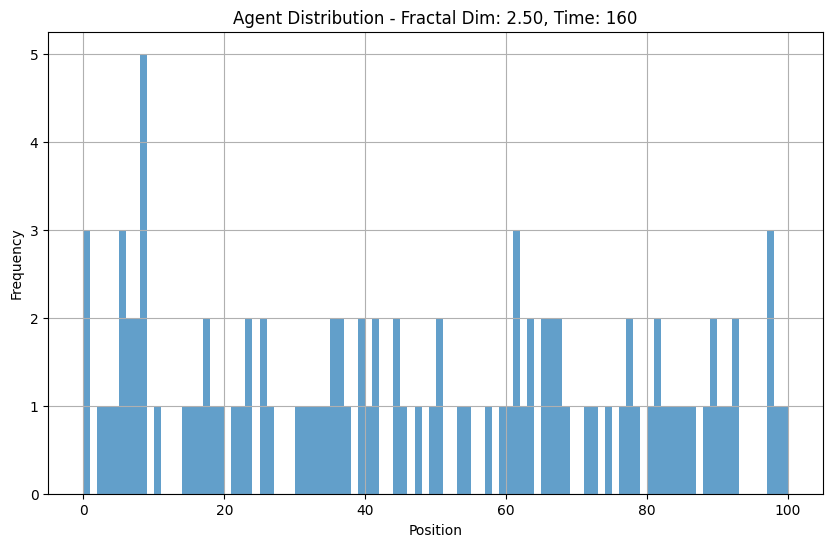

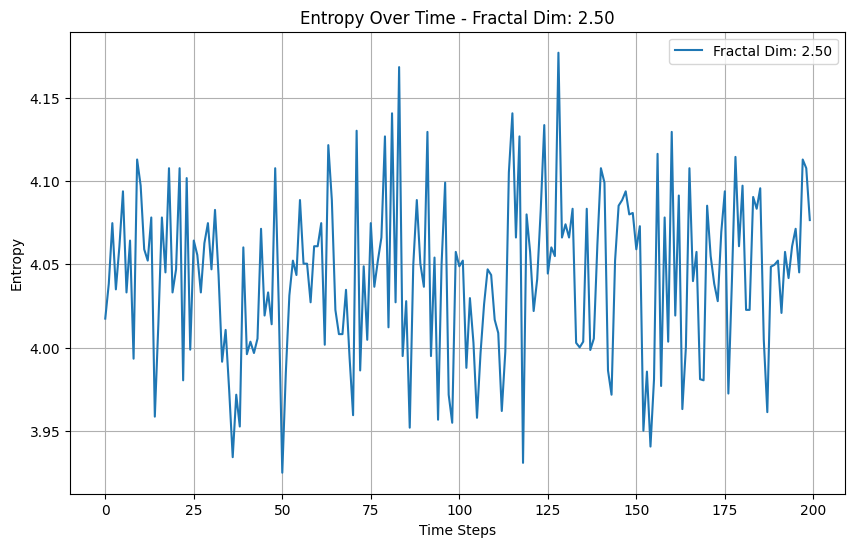

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.spatial.distance import cdist

# Constants
GRID_SIZE = 100  # Size of the grid
NUM_AGENTS = 100  # Number of agents
TIME_STEPS = 200  # Number of simulation steps
DELTA_X = 1.0  # Spatial resolution
FRACTAL_DIMENSIONS = [1.1, 1.5, 2.0, 2.5]  # Fractal dimensions to test

# Initialize agents
def initialize_agents(num_agents, grid_size):
    positions = np.random.randint(0, grid_size, size=(num_agents, 1))
    energies = np.random.uniform(0, 10, size=num_agents)  # Random initial energy
    return positions, energies

# Fractal Laplacian
def fractal_laplacian(grid_size, fractal_dimension):
    diagonal = np.ones(grid_size)
    off_diagonal = np.ones(grid_size - 1)
    laplacian = diags([diagonal, -2 * diagonal, diagonal], [0, -1, 1]).toarray()

    # Fractal scaling: power-law weights for Laplacian
    fractal_weights = np.abs(np.linspace(-grid_size // 2, grid_size // 2, grid_size)) ** (-fractal_dimension)
    fractal_weights /= np.max(fractal_weights)  # Normalize weights
    laplacian *= np.diag(fractal_weights)

    return laplacian / (DELTA_X**2)

# Agent dynamics
def update_agents(positions, energies, laplacian, fractal_dimension):
    # Movement influenced by fractal geometry
    movement = np.random.choice([-1, 0, 1], size=positions.shape)
    positions = positions + movement

    # Apply periodic boundary conditions
    positions = np.mod(positions, GRID_SIZE)

    # Energy dissipation: influenced by fractal Laplacian
    dissipation = np.dot(laplacian, energies)
    energies -= dissipation * 0.01  # Small dissipation step
    energies = np.clip(energies, 0, 10)  # Ensure energy remains non-negative

    return positions, energies

# Entropy calculation
def calculate_entropy(positions, grid_size):
    hist, _ = np.histogram(positions, bins=grid_size, range=(0, grid_size))
    prob = hist / np.sum(hist)
    return -np.sum(prob * np.log(prob + 1e-12))

# Plot agent distribution
def plot_distribution(positions, title):
    plt.figure(figsize=(10, 6))
    plt.hist(positions, bins=GRID_SIZE, range=(0, GRID_SIZE), alpha=0.7)
    plt.title(title)
    plt.xlabel("Position")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

# Main experiment
def main():
    for fractal_dimension in FRACTAL_DIMENSIONS:
        print(f"Simulating for Fractal Dimension: {fractal_dimension:.2f}...")
        laplacian = fractal_laplacian(GRID_SIZE, fractal_dimension)
        positions, energies = initialize_agents(NUM_AGENTS, GRID_SIZE)
        entropies = []

        for t in range(TIME_STEPS):
            positions, energies = update_agents(positions, energies, laplacian, fractal_dimension)
            entropy = calculate_entropy(positions, GRID_SIZE)
            entropies.append(entropy)

            # Plot distribution periodically
            if t % (TIME_STEPS // 5) == 0:
                plot_distribution(positions, f"Agent Distribution - Fractal Dim: {fractal_dimension:.2f}, Time: {t}")

        # Plot entropy over time
        plt.figure(figsize=(10, 6))
        plt.plot(entropies, label=f"Fractal Dim: {fractal_dimension:.2f}")
        plt.title(f"Entropy Over Time - Fractal Dim: {fractal_dimension:.2f}")
        plt.xlabel("Time Steps")
        plt.ylabel("Entropy")
        plt.legend()
        plt.grid()
        plt.show()

if __name__ == "__main__":
    main()

Simulating for Fractal Dimension: 1.50...


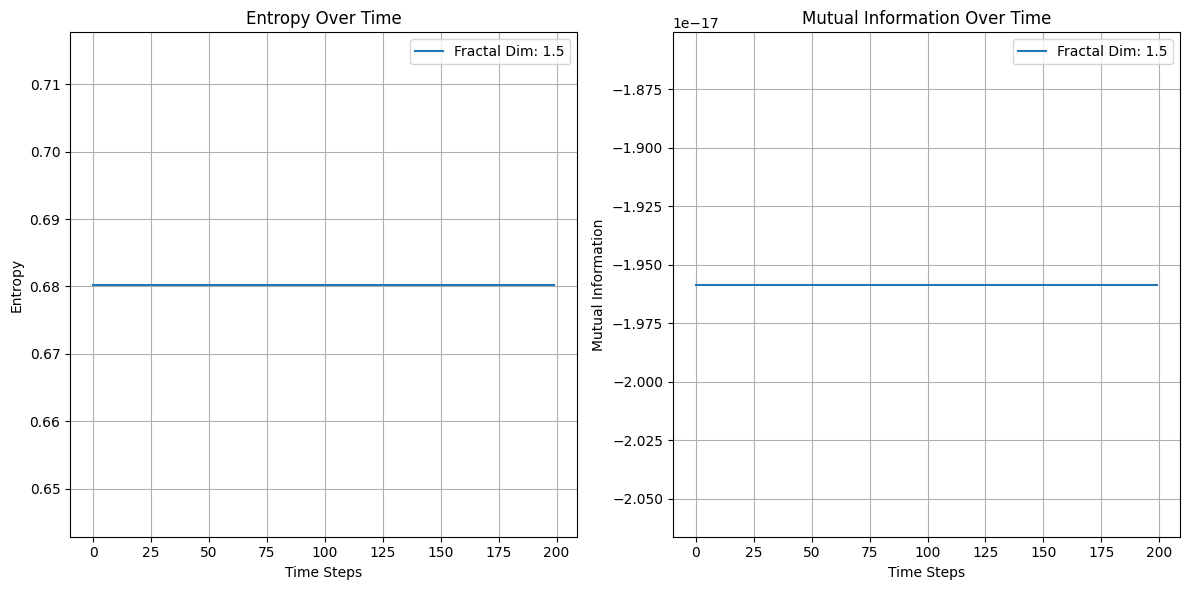

Simulating for Fractal Dimension: 2.00...


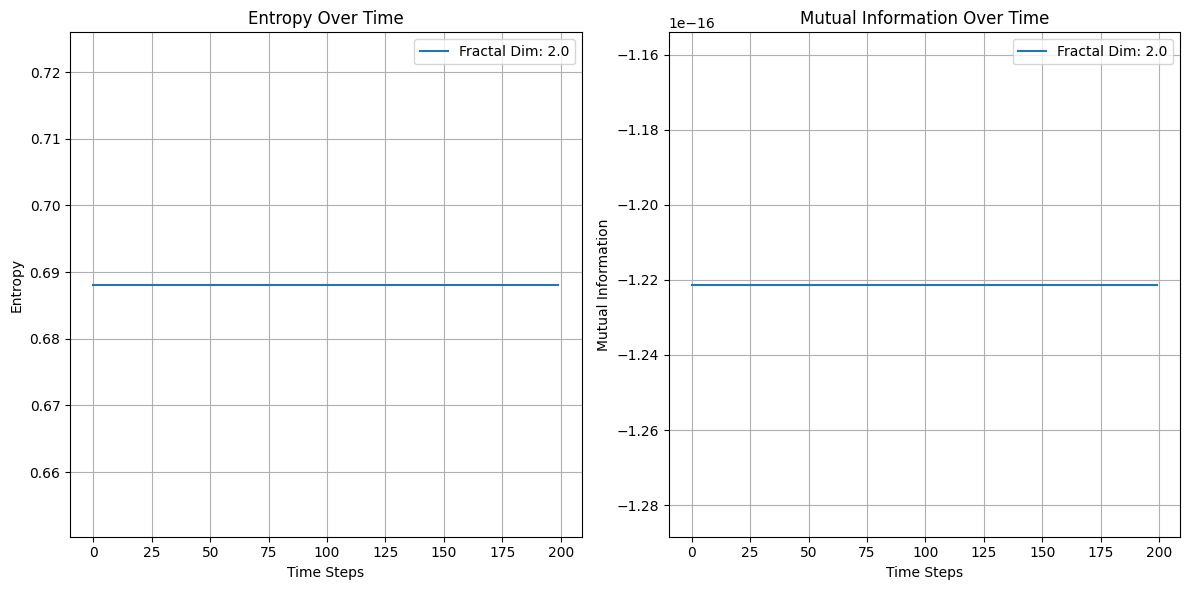

Simulating for Fractal Dimension: 2.50...


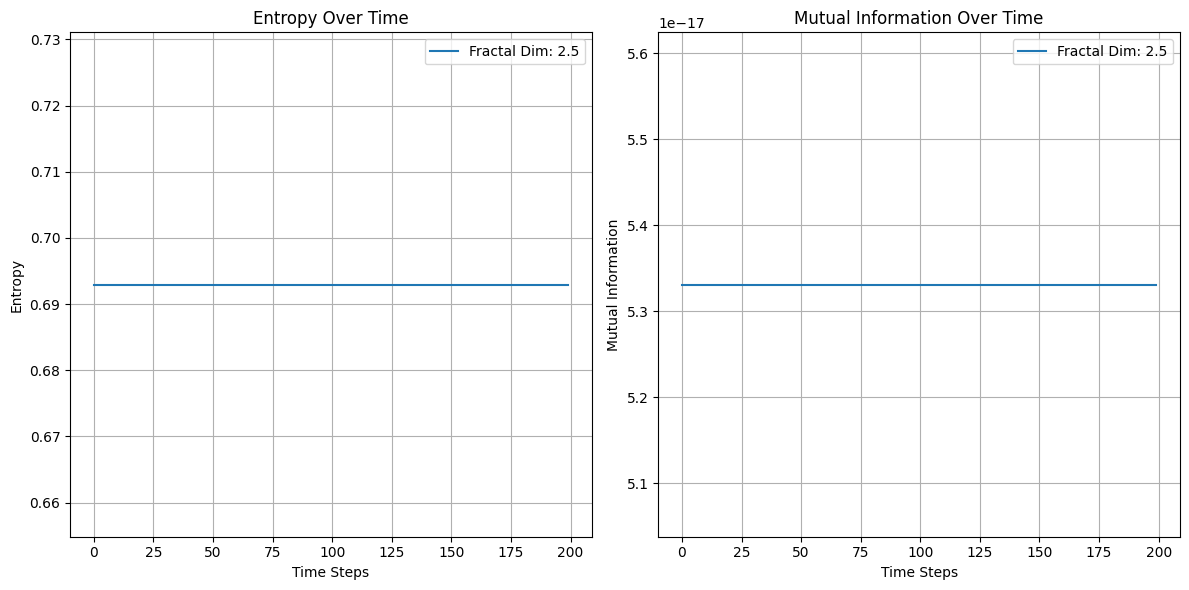

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Constants
GRID_SIZE = 100  # Size of the grid
NUM_AGENTS = 100  # Number of agents
TIME_STEPS = 200  # Number of simulation steps
FRACTAL_DIMENSIONS = [1.5, 2.0, 2.5]  # Fractal dimensions to test

# Initialize agents
def initialize_agents(num_agents, grid_size):
    positions = np.random.randint(0, grid_size, size=(num_agents, 1))
    states = np.random.choice([0, 1], size=num_agents)  # Binary states
    return positions, states

# Fractal Laplacian
def fractal_laplacian(grid_size, fractal_dimension):
    diagonal = np.ones(grid_size)
    off_diagonal = np.ones(grid_size - 1)
    laplacian = diags([diagonal, -2 * diagonal, diagonal], [0, -1, 1]).toarray()

    # Fractal scaling: power-law weights for Laplacian
    fractal_weights = np.abs(np.linspace(-grid_size // 2, grid_size // 2, grid_size)) ** (-fractal_dimension)
    fractal_weights /= np.max(fractal_weights)  # Normalize weights
    laplacian *= np.diag(fractal_weights)

    return laplacian

# Update agent states
def update_states(positions, states, laplacian, fractal_dimension):
    new_states = states.copy()
    for i in range(len(states)):
        # Find neighbors based on fractal Laplacian influence
        probabilities = np.abs(laplacian[i]) / np.sum(np.abs(laplacian[i]))
        neighbor = np.random.choice(np.arange(len(states)), p=probabilities)

        # Entanglement rule: probabilistically align states
        if np.random.rand() < 0.5:  # 50% chance to entangle
            new_states[i] = states[neighbor]

    return new_states

# Mutual Information
def calculate_mutual_information(states):
    # Count joint occurrences of states (0-0, 0-1, 1-0, 1-1)
    joint_probs = np.zeros((2, 2))
    for i in range(len(states)):
        for j in range(len(states)):
            joint_probs[states[i], states[j]] += 1
    joint_probs /= len(states) ** 2

    # Marginal probabilities
    p_x = np.sum(joint_probs, axis=1)
    p_y = np.sum(joint_probs, axis=0)

    # Mutual Information
    mutual_info = 0
    for i in range(2):
        for j in range(2):
            if joint_probs[i, j] > 0:
                mutual_info += joint_probs[i, j] * np.log(joint_probs[i, j] / (p_x[i] * p_y[j]))

    return mutual_info

# Plot results
def plot_results(entropies, mutual_infos, fractal_dimension):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(entropies, label=f"Fractal Dim: {fractal_dimension}")
    plt.title("Entropy Over Time")
    plt.xlabel("Time Steps")
    plt.ylabel("Entropy")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(mutual_infos, label=f"Fractal Dim: {fractal_dimension}")
    plt.title("Mutual Information Over Time")
    plt.xlabel("Time Steps")
    plt.ylabel("Mutual Information")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

# Main experiment
def main():
    for fractal_dimension in FRACTAL_DIMENSIONS:
        print(f"Simulating for Fractal Dimension: {fractal_dimension:.2f}...")
        laplacian = fractal_laplacian(GRID_SIZE, fractal_dimension)
        positions, states = initialize_agents(NUM_AGENTS, GRID_SIZE)

        entropies = []
        mutual_infos = []

        for t in range(TIME_STEPS):
            states = update_states(positions, states, laplacian, fractal_dimension)

            # Calculate metrics
            entropy = -np.sum(np.bincount(states, minlength=2) / NUM_AGENTS * np.log(np.bincount(states, minlength=2) / NUM_AGENTS + 1e-12))
            mutual_info = calculate_mutual_information(states)

            entropies.append(entropy)
            mutual_infos.append(mutual_info)

        # Plot results
        plot_results(entropies, mutual_infos, fractal_dimension)

if __name__ == "__main__":
    main()

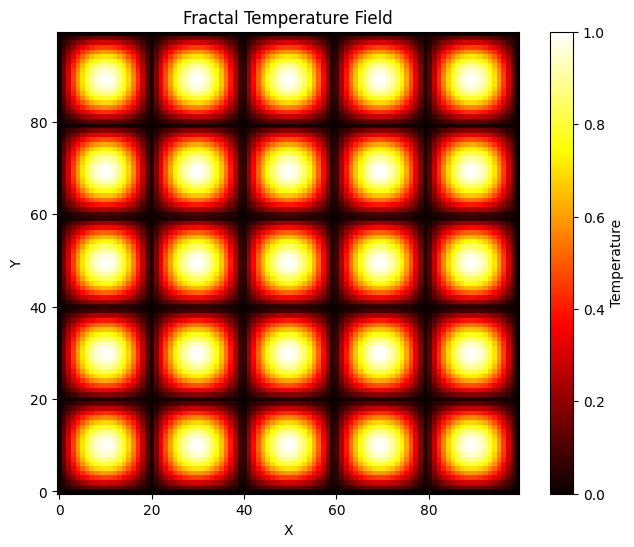

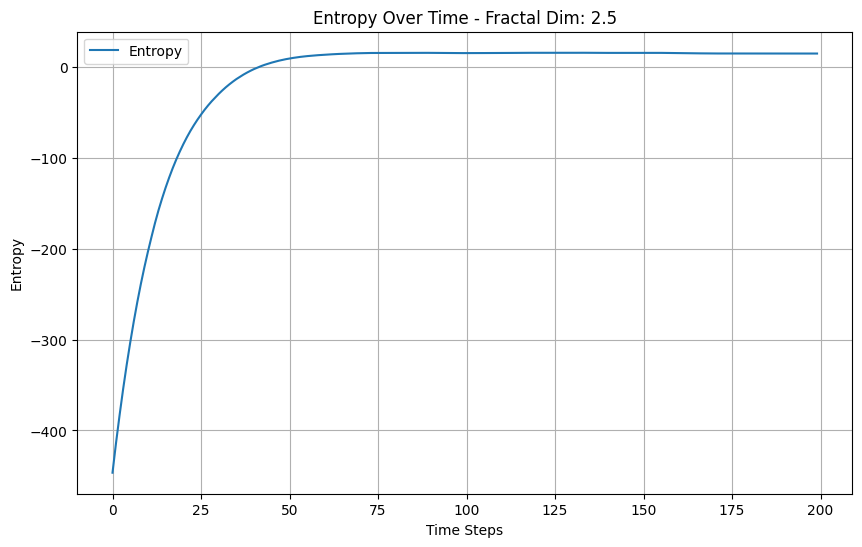

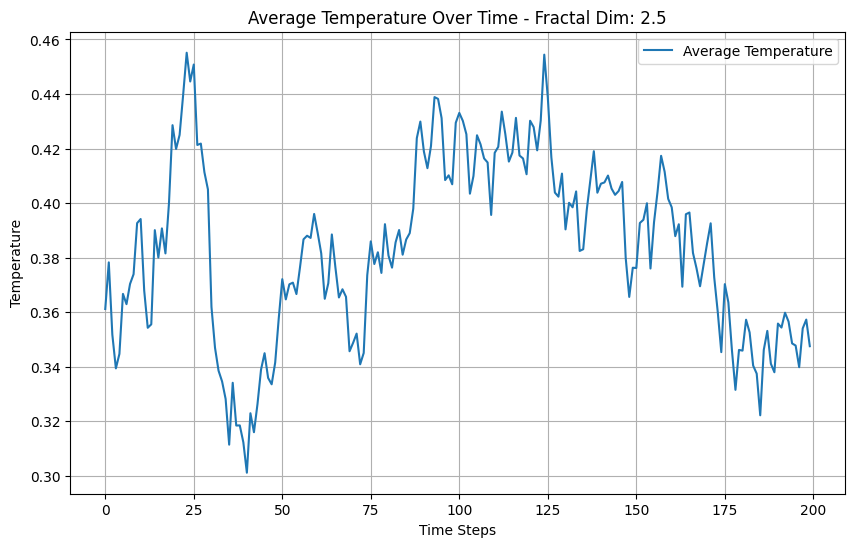

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags

# Constants
GRID_SIZE = 100
TIME_STEPS = 200
NUM_AGENTS = 50
FRACTAL_DIM = 2.5
DELTA_T = 0.1

# Initialize fractal temperature field
def initialize_fractal_temperature(grid_size, fractal_dim):
    x = np.linspace(0, 1, grid_size)
    y = np.linspace(0, 1, grid_size)
    xx, yy = np.meshgrid(x, y)
    fractal_field = np.abs(np.sin(2 * np.pi * fractal_dim * xx) * np.sin(2 * np.pi * fractal_dim * yy))
    return fractal_field / np.max(fractal_field)  # Normalize

# Initialize agents with positions and energy
def initialize_agents(num_agents, grid_size):
    positions = np.random.randint(0, grid_size, size=(num_agents, 2))
    energy = np.random.rand(num_agents) * 10  # Random energy levels between 0 and 10
    return positions, energy

# Agent movement in fractal space
def move_agents(positions, grid_size):
    moves = np.random.randint(-1, 2, size=positions.shape)  # Random walk
    new_positions = positions + moves
    new_positions = np.clip(new_positions, 0, grid_size - 1)  # Stay within bounds
    return new_positions

# Energy exchange between agents
def energy_exchange(positions, energy, temperature_field):
    for i, pos in enumerate(positions):
        # Find nearby agents
        neighbors = np.linalg.norm(positions - pos, axis=1) <= 1.0
        neighbor_indices = np.where(neighbors)[0]

        # Exchange energy with neighbors
        for j in neighbor_indices:
            if i != j:
                delta_e = (energy[i] - energy[j]) * 0.1  # Fractional energy exchange
                energy[i] -= delta_e
                energy[j] += delta_e

        # Interact with the fractal temperature field
        temp = temperature_field[pos[0], pos[1]]
        energy[i] += (temp - energy[i]) * 0.05  # Energy converges toward the local temperature
    return energy

# Calculate system-wide thermodynamic metrics
def calculate_metrics(energy, positions, temperature_field):
    entropy = -np.sum(energy * np.log(energy + 1e-9))
    avg_temperature = np.mean([temperature_field[pos[0], pos[1]] for pos in positions])
    return entropy, avg_temperature

# Plot temperature field
def plot_temperature_field(temperature_field):
    plt.figure(figsize=(8, 6))
    plt.imshow(temperature_field, cmap="hot", origin="lower")
    plt.colorbar(label="Temperature")
    plt.title("Fractal Temperature Field")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(False)
    plt.show()

# Main experiment
def main():
    # Initialize fractal temperature field
    temperature_field = initialize_fractal_temperature(GRID_SIZE, FRACTAL_DIM)
    plot_temperature_field(temperature_field)

    # Initialize agents
    positions, energy = initialize_agents(NUM_AGENTS, GRID_SIZE)

    # Track metrics over time
    entropy_over_time = []
    avg_temperature_over_time = []

    for t in range(TIME_STEPS):
        positions = move_agents(positions, GRID_SIZE)
        energy = energy_exchange(positions, energy, temperature_field)
        entropy, avg_temp = calculate_metrics(energy, positions, temperature_field)
        entropy_over_time.append(entropy)
        avg_temperature_over_time.append(avg_temp)

    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(entropy_over_time, label="Entropy")
    plt.title(f"Entropy Over Time - Fractal Dim: {FRACTAL_DIM}")
    plt.xlabel("Time Steps")
    plt.ylabel("Entropy")
    plt.grid()
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(avg_temperature_over_time, label="Average Temperature")
    plt.title(f"Average Temperature Over Time - Fractal Dim: {FRACTAL_DIM}")
    plt.xlabel("Time Steps")
    plt.ylabel("Temperature")
    plt.grid()
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()

Simulating for Fractal Dimension: 1.5...


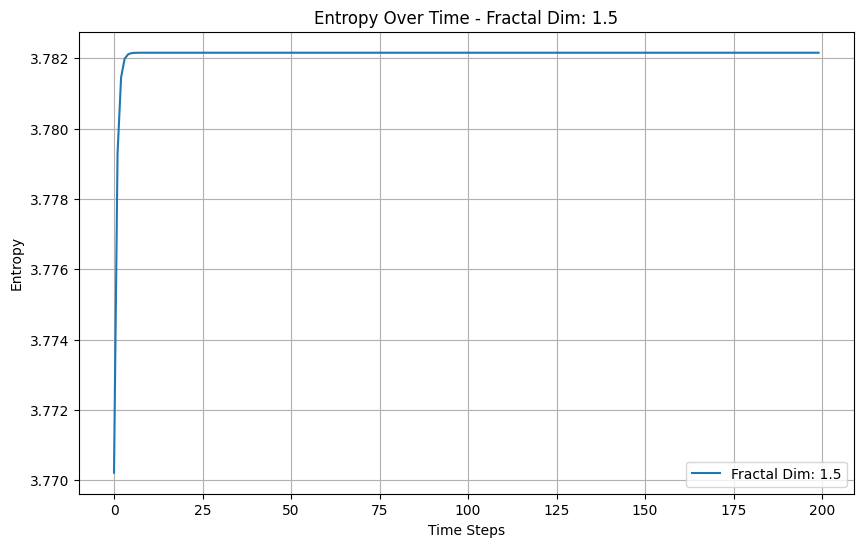

Simulating for Fractal Dimension: 2.0...


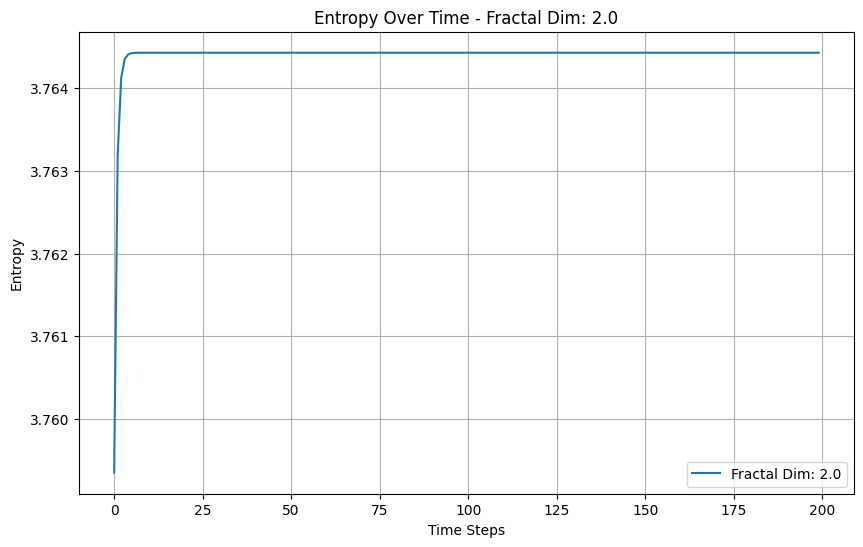

Simulating for Fractal Dimension: 2.5...


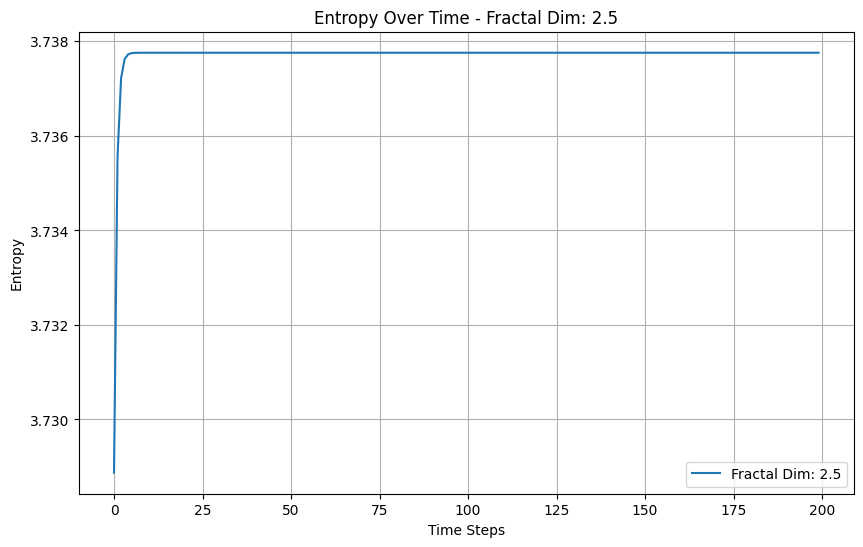

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

# Constants
GRID_SIZE = 100
TIME_STEPS = 200
FRACTAL_DIMENSIONS = [1.5, 2.0, 2.5]
PERTURBATION_TIMESTEP = 100  # Introduce perturbation at this timestep

# Initialize agents with random positions and energy levels
def initialize_agents(num_agents, grid_size):
    positions = np.random.randint(0, grid_size, size=(num_agents, 1))
    energies = np.random.rand(num_agents)  # Random initial energy
    return positions, energies

# Fractal interaction function
def fractal_interaction(positions, energies, fractal_dim, grid_size):
    distances = squareform(pdist(positions))
    distances = np.maximum(distances, 1e-9)  # Avoid division by zero
    interaction_strength = distances ** (-fractal_dim)  # Fractal decay
    energy_transfer = interaction_strength @ energies
    normalized_transfer = energy_transfer / np.sum(interaction_strength, axis=1)
    energies += normalized_transfer - energies * 0.01  # Include energy dissipation
    return energies

# Perturbation function
def apply_perturbation(energies):
    perturbation = np.random.rand(len(energies)) * 5  # Sudden energy spike
    energies += perturbation
    return energies

# Calculate entropy
def calculate_entropy(energies):
    probabilities = energies / np.sum(energies)
    return -np.sum(probabilities * np.log(probabilities + 1e-12))

# Run the simulation
def simulate(fractal_dim, grid_size, num_agents, time_steps, perturbation_timestep):
    positions, energies = initialize_agents(num_agents, grid_size)
    entropy_over_time = []

    for t in range(time_steps):
        if t == perturbation_timestep:
            energies = apply_perturbation(energies)

        energies = fractal_interaction(positions, energies, fractal_dim, grid_size)
        entropy_over_time.append(calculate_entropy(energies))

    return entropy_over_time

# Plot results
def plot_entropy(fractal_dim, entropy_over_time):
    plt.figure(figsize=(10, 6))
    plt.plot(entropy_over_time, label=f"Fractal Dim: {fractal_dim}")
    plt.title(f"Entropy Over Time - Fractal Dim: {fractal_dim}")
    plt.xlabel("Time Steps")
    plt.ylabel("Entropy")
    plt.legend()
    plt.grid()
    plt.show()

# Main experiment
def main():
    num_agents = 50
    for fractal_dim in FRACTAL_DIMENSIONS:
        print(f"Simulating for Fractal Dimension: {fractal_dim}...")
        entropy_over_time = simulate(fractal_dim, GRID_SIZE, num_agents, TIME_STEPS, PERTURBATION_TIMESTEP)
        plot_entropy(fractal_dim, entropy_over_time)

if __name__ == "__main__":
    main()

Simulating for Euclidean Geometry...


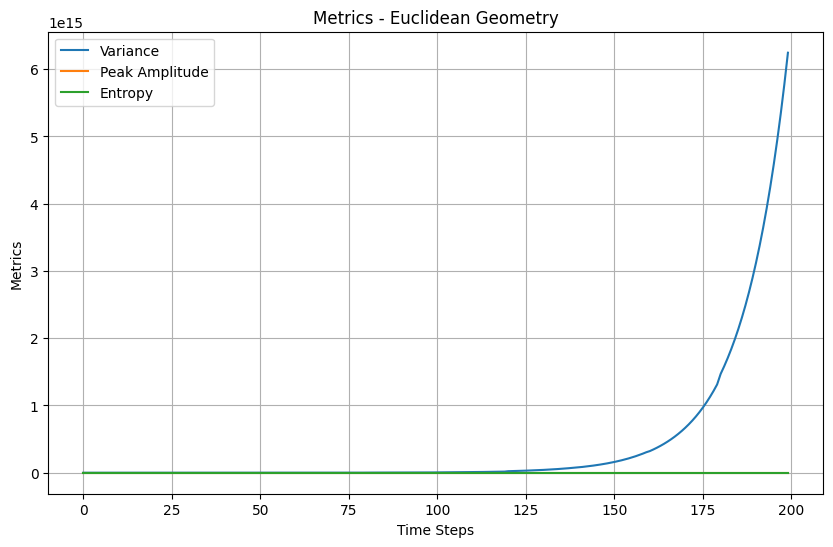

Simulating for Hyperbolic Geometry...


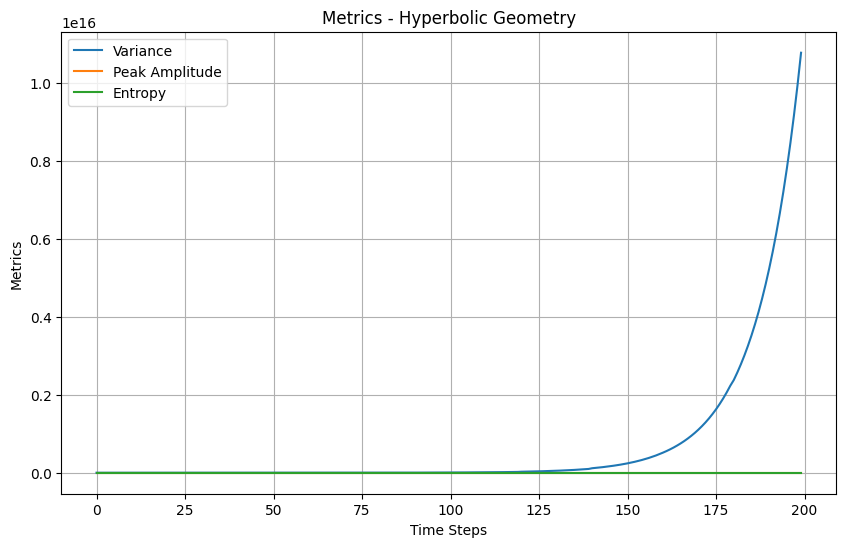

Simulating for Spherical Geometry...


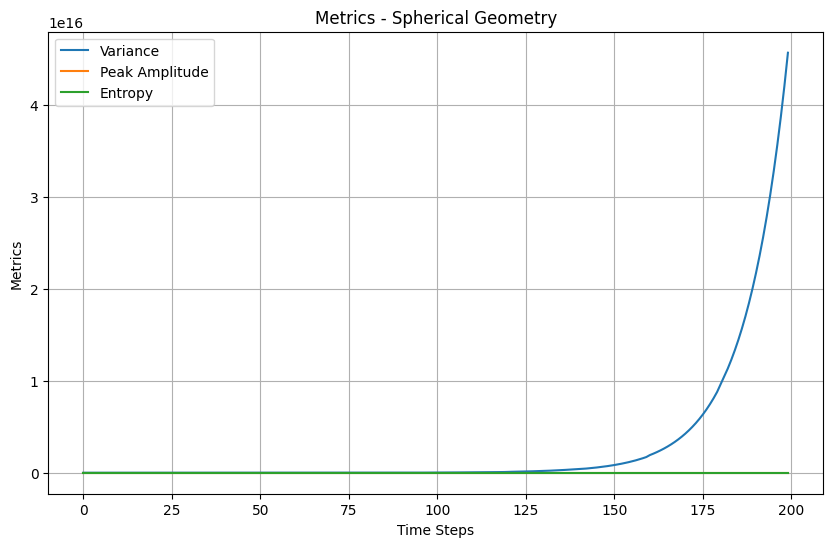

Simulating for Fractal Geometry...


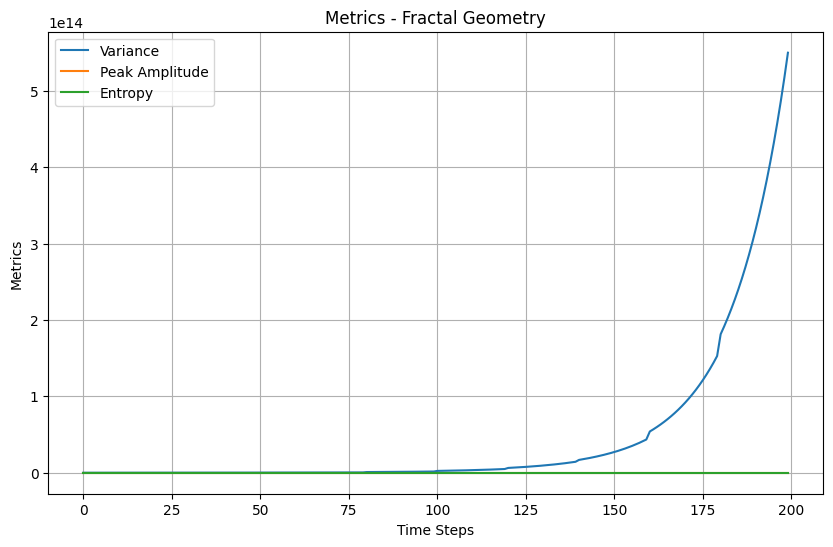

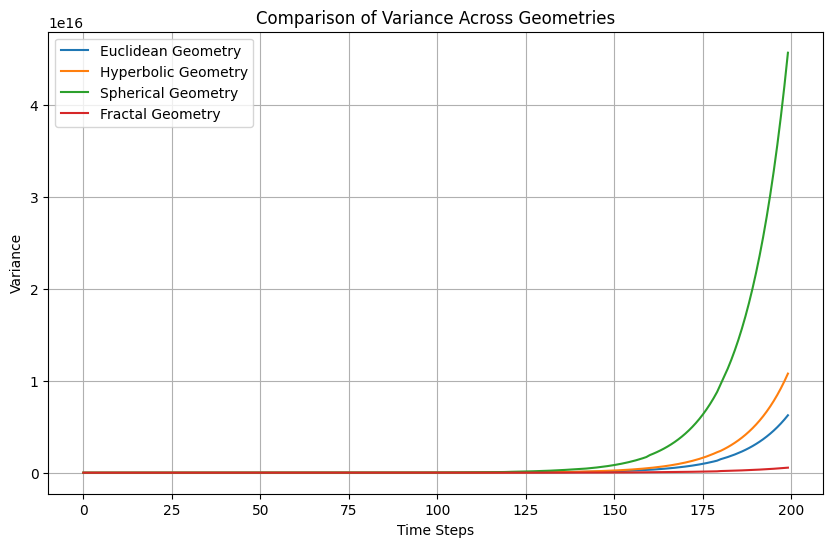

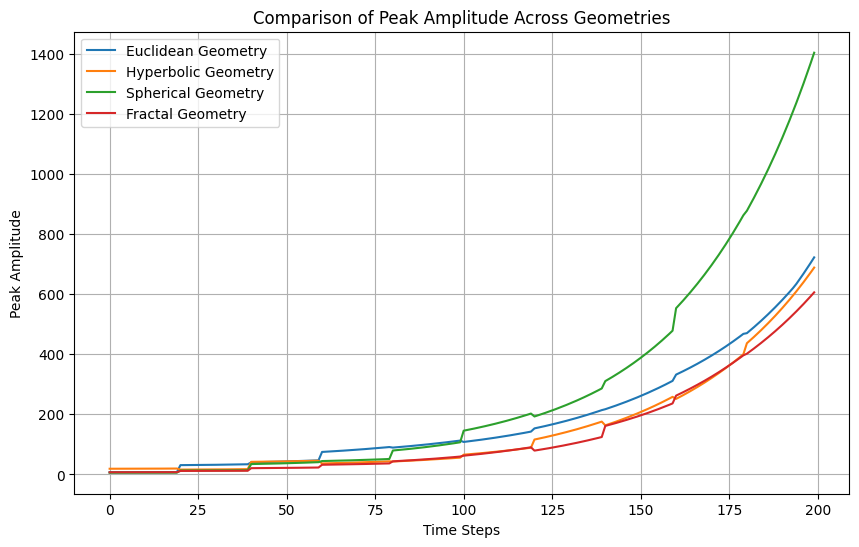

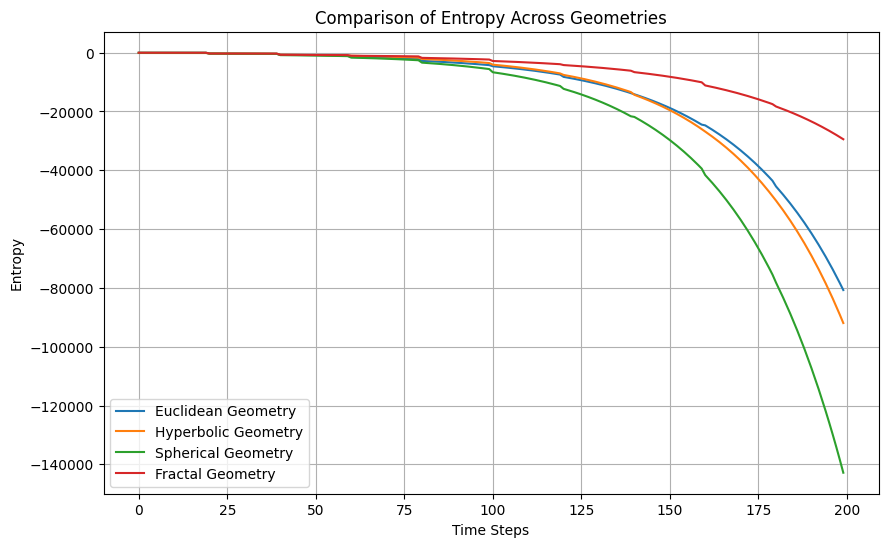

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.linalg import expm

# Constants
GRID_SIZE = 100  # Size of the 2D grid
TIME_STEPS = 200  # Number of time steps
DELTA_X = 1.0  # Spatial resolution
DELTA_T = 0.01  # Time step
H_BAR = 1.0  # Reduced Planck's constant
MASS = 1.0  # Mass of the particle
PERTURBATION_INTERVAL = 20  # Time steps between perturbations
PERTURBATION_MAGNITUDE = 1.0  # Strength of perturbation
CURVATURE_TYPES = ["Euclidean", "Hyperbolic", "Spherical", "Fractal"]
FRACTAL_DIMENSION = 2.5

# Laplacian operator for different geometries
def laplacian_operator(grid_size, curvature="Euclidean"):
    diagonal = np.ones(grid_size)
    off_diagonal = np.ones(grid_size - 1)
    laplacian = diags([diagonal, -2 * diagonal, diagonal], [0, -1, 1]).toarray()

    if curvature == "Hyperbolic":
        laplacian -= np.diag(np.exp(np.linspace(-1, -2, grid_size)))
    elif curvature == "Spherical":
        laplacian += np.diag(np.linspace(1, 1 / grid_size, grid_size))
    elif curvature == "Fractal":
        laplacian *= np.abs(np.sin(np.linspace(0, np.pi * FRACTAL_DIMENSION, grid_size)))

    return laplacian / (DELTA_X**2)

# Initialize wavefunction
def initialize_wavefunction(grid_size):
    x = np.linspace(-grid_size // 2, grid_size // 2, grid_size)
    psi = np.exp(-(x**2) / 20.0) * np.exp(1j * 2.0 * np.pi * x / grid_size)
    return psi / np.linalg.norm(psi)

# Time evolution of the wavefunction with perturbations
def evolve_wavefunction(psi, laplacian, time_steps, delta_t):
    hamiltonian = -H_BAR**2 / (2 * MASS) * laplacian
    evolution_operator = expm(-1j * hamiltonian * delta_t / H_BAR)
    psi_t = []

    for t in range(time_steps):
        if t % PERTURBATION_INTERVAL == 0:
            perturbation = np.random.normal(scale=PERTURBATION_MAGNITUDE, size=psi.shape)
            psi += perturbation

        psi = evolution_operator @ psi
        psi_t.append(np.abs(psi)**2)

    return np.array(psi_t)

# Calculate quantitative metrics
def calculate_metrics(psi_t):
    variances = []
    peak_amplitudes = []
    entropies = []

    for prob_density in psi_t:
        # Variance
        x = np.arange(len(prob_density))
        mean = np.sum(x * prob_density)
        variance = np.sum(((x - mean) ** 2) * prob_density)
        variances.append(variance)

        # Peak amplitude
        peak_amplitude = np.max(prob_density)
        peak_amplitudes.append(peak_amplitude)

        # Shannon entropy
        entropy = -np.sum(prob_density * np.log(prob_density + 1e-12))
        entropies.append(entropy)

    return variances, peak_amplitudes, entropies

# Plot metrics
def plot_metrics(metrics, curvature_type, metric_name):
    plt.figure(figsize=(10, 6))
    for metric, label in zip(metrics, ["Variance", "Peak Amplitude", "Entropy"]):
        plt.plot(metric, label=label)
    plt.title(f"{metric_name} - {curvature_type} Geometry")
    plt.xlabel("Time Steps")
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid()
    plt.show()

# Main experiment
def main():
    all_metrics = {}

    for curvature_type in CURVATURE_TYPES:
        print(f"Simulating for {curvature_type} Geometry...")
        laplacian = laplacian_operator(GRID_SIZE, curvature=curvature_type)
        psi = initialize_wavefunction(GRID_SIZE)
        psi_t = evolve_wavefunction(psi, laplacian, TIME_STEPS, DELTA_T)

        # Calculate metrics
        variances, peak_amplitudes, entropies = calculate_metrics(psi_t)
        all_metrics[curvature_type] = {
            "Variance": variances,
            "Peak Amplitude": peak_amplitudes,
            "Entropy": entropies,
        }

        # Plot evolution
        plot_metrics([variances, peak_amplitudes, entropies], curvature_type, "Metrics")

    # Compare metrics
    for metric_name in ["Variance", "Peak Amplitude", "Entropy"]:
        plt.figure(figsize=(10, 6))
        for curvature_type in CURVATURE_TYPES:
            plt.plot(
                all_metrics[curvature_type][metric_name],
                label=f"{curvature_type} Geometry",
            )
        plt.title(f"Comparison of {metric_name} Across Geometries")
        plt.xlabel("Time Steps")
        plt.ylabel(metric_name)
        plt.legend()
        plt.grid()
        plt.show()

if __name__ == "__main__":
    main()

Simulating for Fractal Dimension: 1.5...


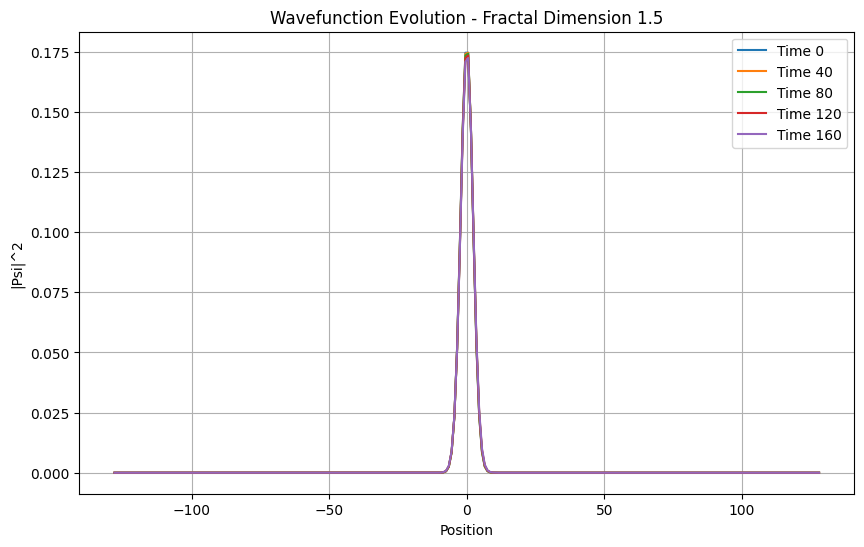

Simulating for Fractal Dimension: 2.0...


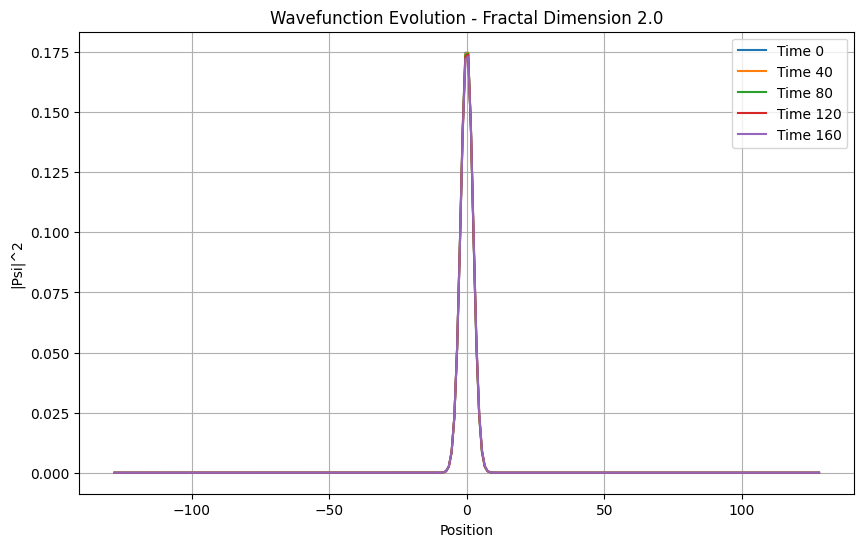

Simulating for Fractal Dimension: 2.5...


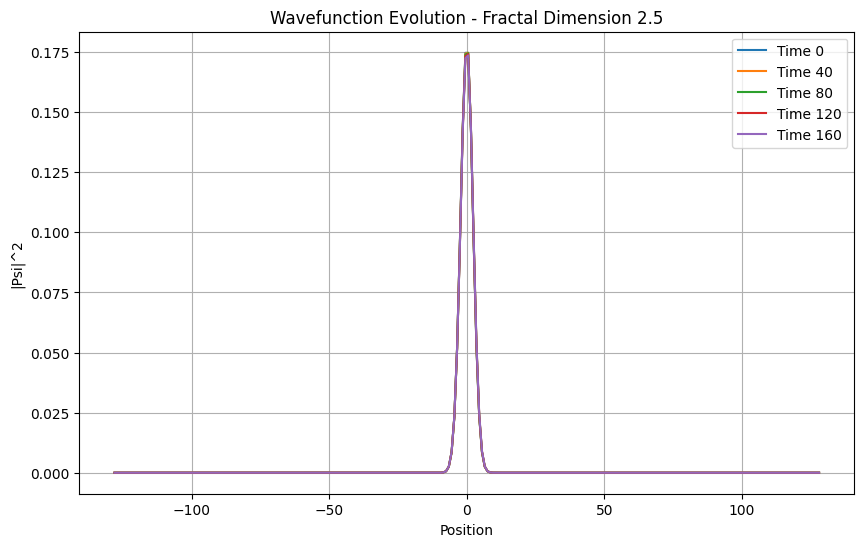

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft, fftfreq
from scipy.sparse import diags

# Constants
GRID_SIZE = 256  # Spatial grid points
TIME_STEPS = 200  # Number of time steps
DELTA_X = 1.0  # Spatial resolution
DELTA_T = 0.01  # Time step
H_BAR = 1.0  # Reduced Planck's constant
MASS = 1.0  # Mass of the particle
FRACTAL_DIMENSIONS = [1.5, 2.0, 2.5]  # Test different fractal dimensions

# Fractional Laplacian operator
def fractional_laplacian(grid_size, alpha):
    k = fftfreq(grid_size, d=DELTA_X)  # Frequency components
    k = 2 * np.pi * k
    laplacian = np.abs(k) ** alpha  # Fractional Laplacian in Fourier space
    return laplacian

# Initialize wavefunction
def initialize_wavefunction(grid_size):
    x = np.linspace(-grid_size // 2, grid_size // 2, grid_size)
    psi = np.exp(-(x**2) / 20.0) * np.exp(1j * 2.0 * np.pi * x / grid_size)
    return psi / np.linalg.norm(psi), x

# Time evolution using fractional Schrödinger equation
def evolve_wavefunction(psi, laplacian, time_steps, delta_t):
    psi_t = []
    for _ in range(time_steps):
        # Apply fractional Laplacian in Fourier space
        psi_fft = fft(psi)
        psi_fft = np.exp(-1j * laplacian * delta_t / (2 * MASS)) * psi_fft
        psi = ifft(psi_fft)
        psi_t.append(np.abs(psi)**2)
    return np.array(psi_t)

# Plot results
def plot_results(psi_t, x, fractal_dim):
    plt.figure(figsize=(10, 6))
    for t in range(0, len(psi_t), len(psi_t) // 5):
        plt.plot(x, psi_t[t], label=f"Time {t}")
    plt.title(f"Wavefunction Evolution - Fractal Dimension {fractal_dim}")
    plt.xlabel("Position")
    plt.ylabel("|Psi|^2")
    plt.legend()
    plt.grid()
    plt.show()

# Main experiment
def main():
    for fractal_dim in FRACTAL_DIMENSIONS:
        print(f"Simulating for Fractal Dimension: {fractal_dim}...")
        laplacian = fractional_laplacian(GRID_SIZE, fractal_dim)
        psi, x = initialize_wavefunction(GRID_SIZE)
        psi_t = evolve_wavefunction(psi, laplacian, TIME_STEPS, DELTA_T)
        plot_results(psi_t, x, fractal_dim)

if __name__ == "__main__":
    main()


Simulating for Euclidean Geometry...
Simulating for Hyperbolic Geometry...
Simulating for Spherical Geometry...
Simulating for Fractal Geometry with Dimension 1.5...
Simulating for Fractal Geometry with Dimension 2.0...
Simulating for Fractal Geometry with Dimension 2.5...


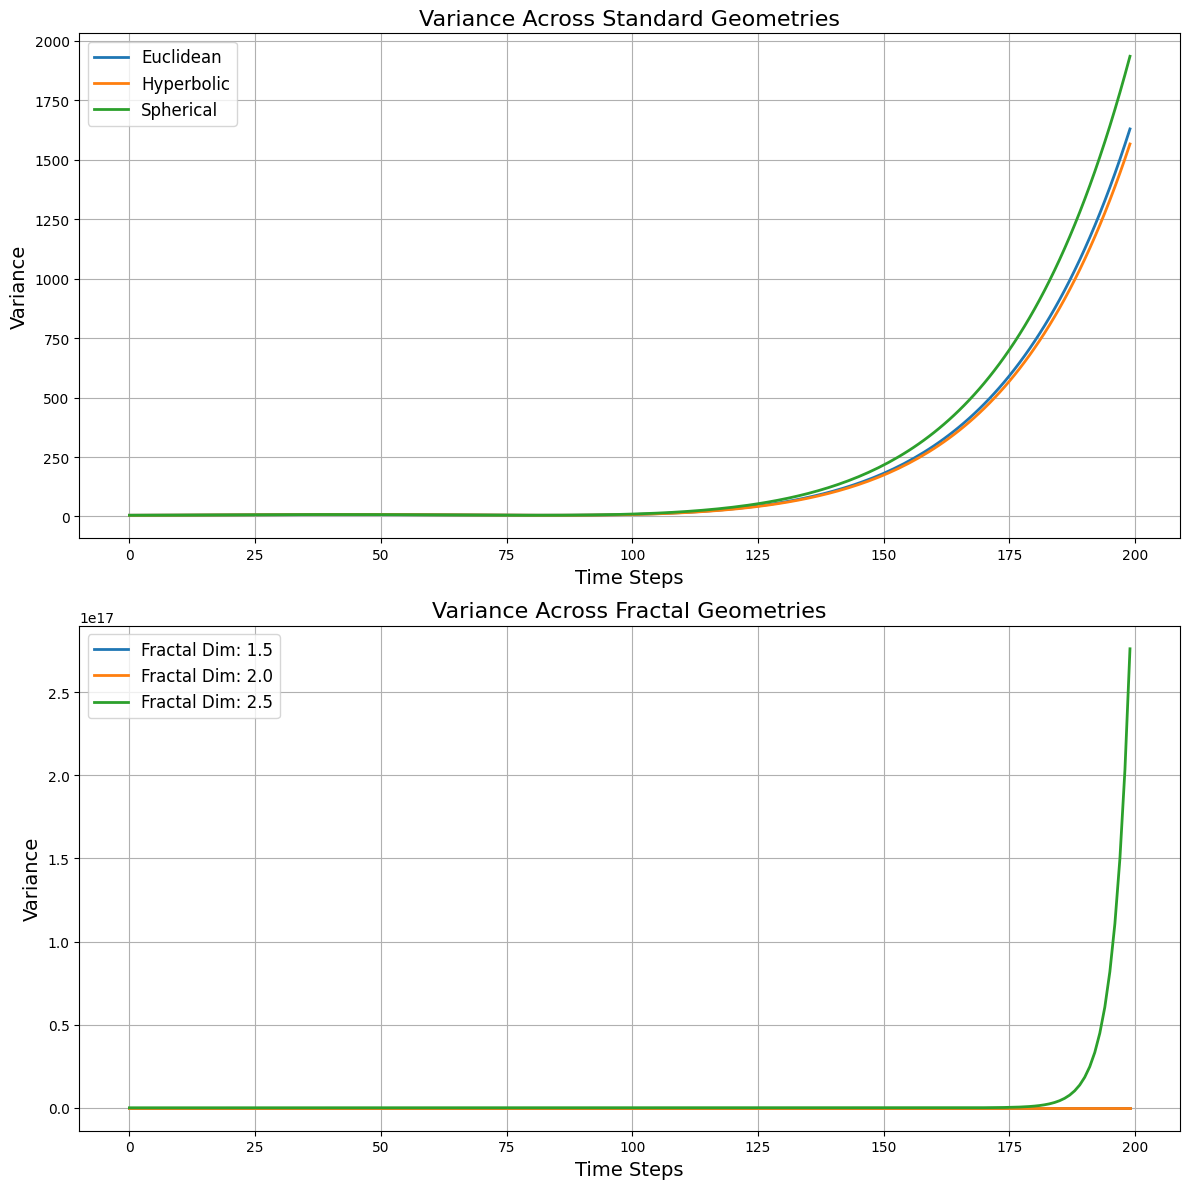

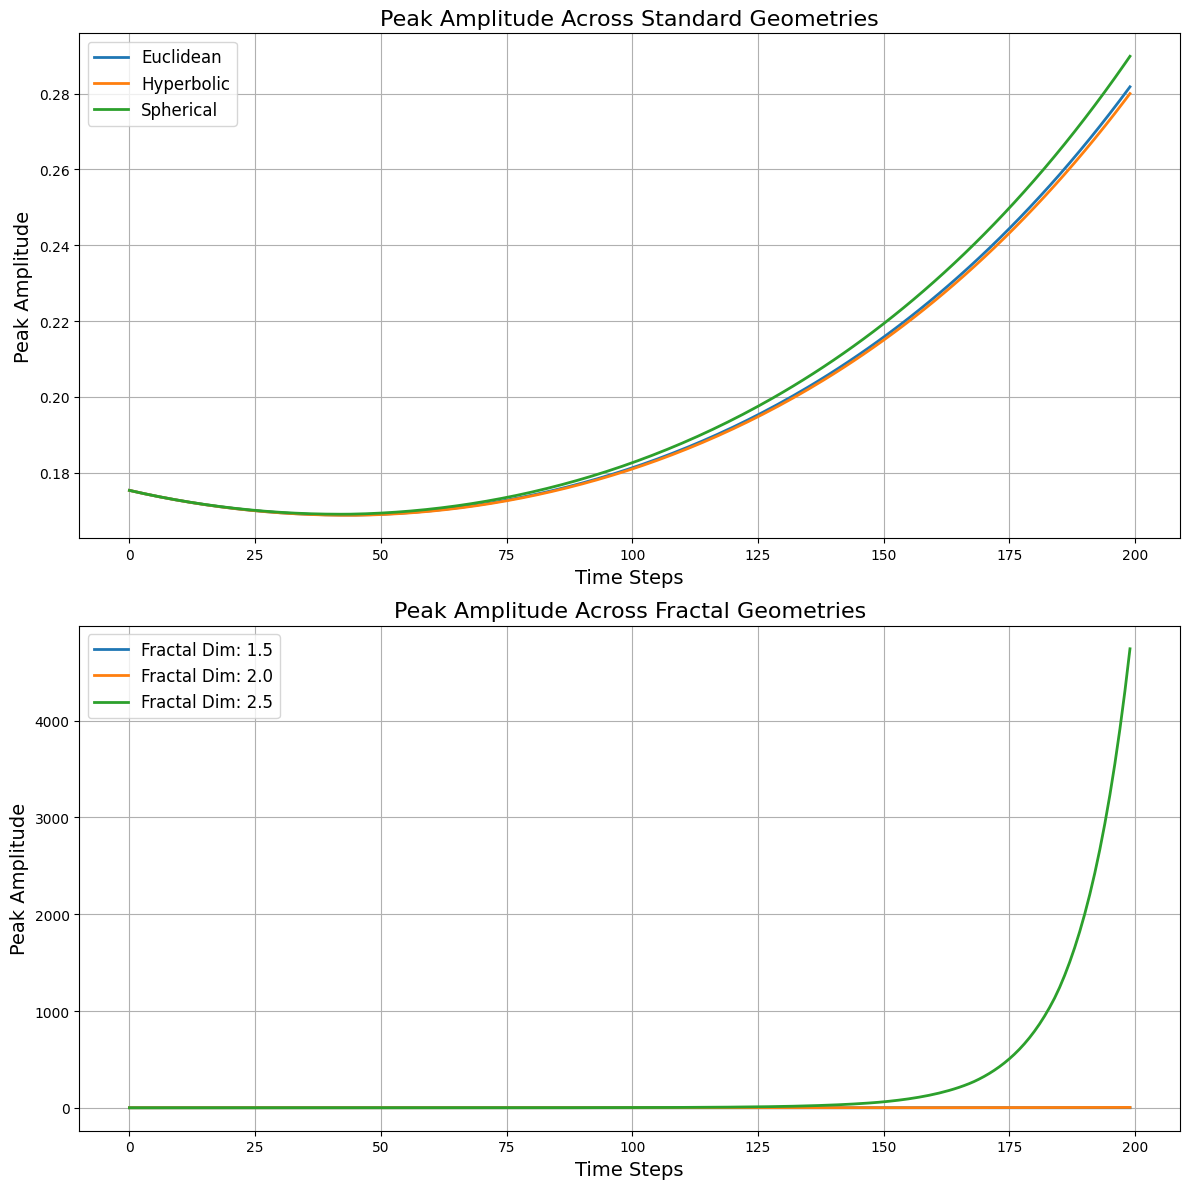

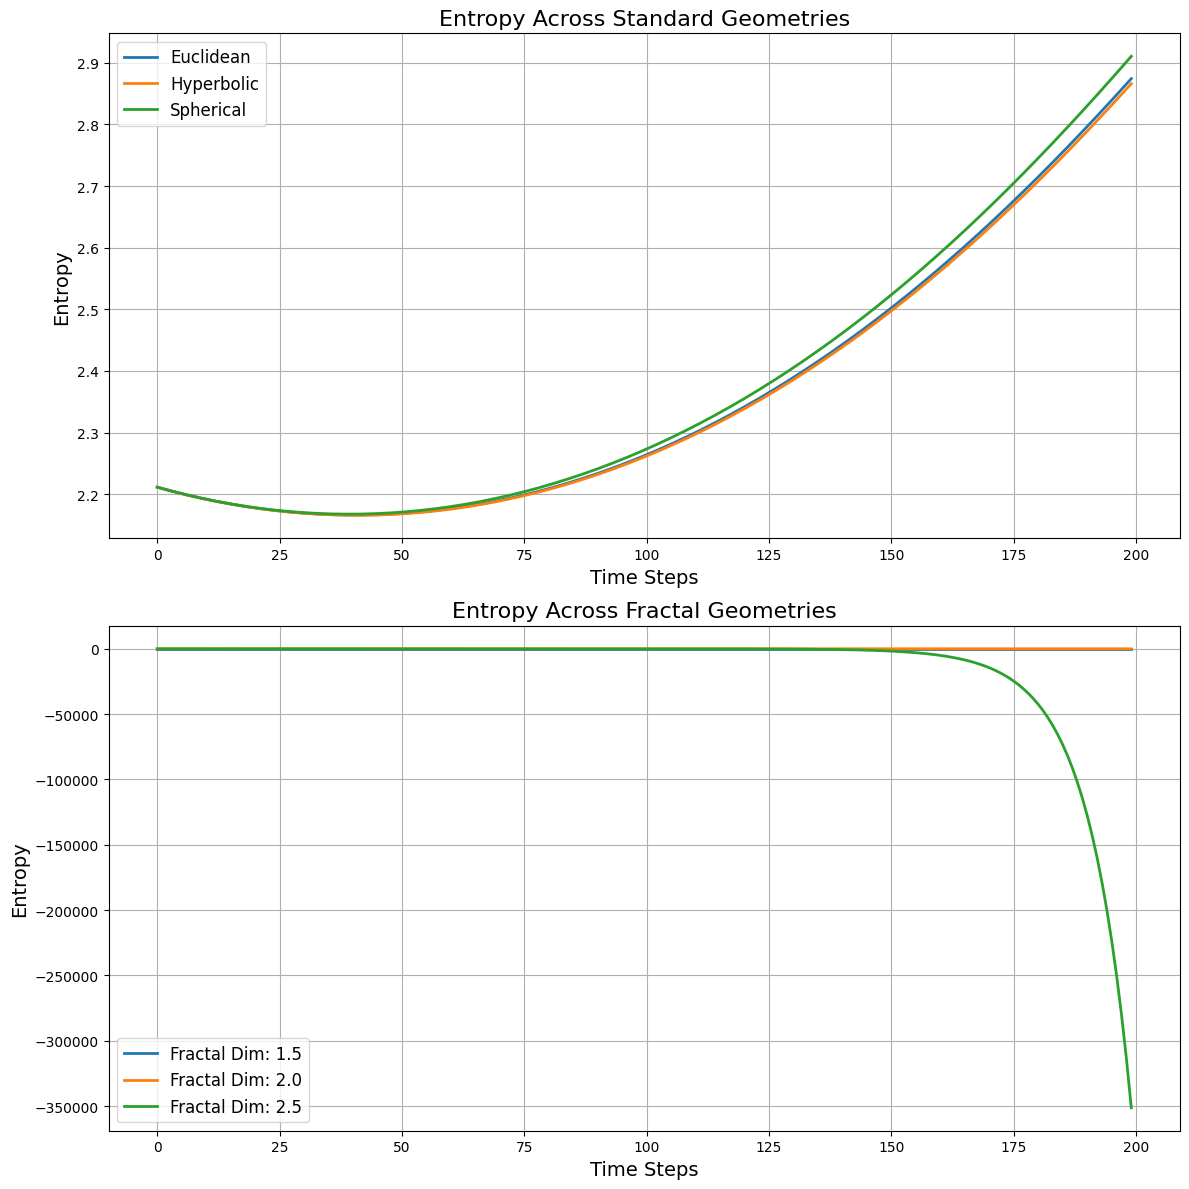

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.linalg import expm

# Constants
GRID_SIZE = 100  # Number of grid points
TIME_STEPS = 200  # Number of time steps
DELTA_X = 1.0  # Spatial resolution
DELTA_T = 0.01  # Time step
H_BAR = 1.0  # Reduced Planck's constant
MASS = 1.0  # Mass of the particle
GEOMETRIES = ["Euclidean", "Hyperbolic", "Spherical", "Fractal"]
FRACTAL_DIMENSIONS = [1.5, 2.0, 2.5]  # Example fractal dimensions

# Laplacian operator for each geometry
def laplacian_operator(grid_size, geometry, fractal_dim=None):
    diagonal = np.ones(grid_size)
    off_diagonal = np.ones(grid_size - 1)
    laplacian = diags([diagonal, -2 * diagonal, diagonal], [0, -1, 1]).toarray()

    if geometry == "Hyperbolic":
        laplacian -= np.diag(np.exp(np.linspace(-1, -2, grid_size)))
    elif geometry == "Spherical":
        laplacian += np.diag(np.linspace(1, 1 / grid_size, grid_size))
    elif geometry == "Fractal" and fractal_dim is not None:
        fractional_scaling = np.linspace(1, fractal_dim, grid_size) ** fractal_dim
        laplacian = diags([fractional_scaling, -2 * fractional_scaling, fractional_scaling], [0, -1, 1]).toarray()

    return laplacian / (DELTA_X**2)

# Initialize wavefunction
def initialize_wavefunction(grid_size):
    x = np.linspace(-grid_size // 2, grid_size // 2, grid_size)
    psi = np.exp(-(x**2) / 20.0) * np.exp(1j * 2.0 * np.pi * x / grid_size)
    return psi / np.linalg.norm(psi)

# Time evolution of the wavefunction
def evolve_wavefunction(psi, laplacian, time_steps, delta_t):
    hamiltonian = -H_BAR**2 / (2 * MASS) * laplacian
    evolution_operator = expm(-1j * hamiltonian * delta_t / H_BAR)
    psi_t = []

    for _ in range(time_steps):
        psi = evolution_operator @ psi
        psi_t.append(np.abs(psi)**2)

    return np.array(psi_t)

# Calculate metrics
def calculate_metrics(psi_t):
    variances = []
    peak_amplitudes = []
    entropies = []

    for prob_density in psi_t:
        # Variance
        x = np.arange(len(prob_density))
        mean = np.sum(x * prob_density)
        variance = np.sum(((x - mean) ** 2) * prob_density)
        variances.append(variance)

        # Peak amplitude
        peak_amplitude = np.max(prob_density)
        peak_amplitudes.append(peak_amplitude)

        # Shannon entropy
        entropy = -np.sum(prob_density * np.log(prob_density + 1e-12))
        entropies.append(entropy)

    return variances, peak_amplitudes, entropies

# Plot comparison across geometries
def plot_comparison(comparison_metrics, metric_name):
    plt.figure(figsize=(12, 12))

    # Subplot for standard geometries
    plt.subplot(2, 1, 1)
    for geometry, metrics in comparison_metrics.items():
        if "Fractal" not in geometry:
            plt.plot(metrics, label=geometry, linewidth=2)
    plt.title(f"{metric_name} Across Standard Geometries", fontsize=16)
    plt.xlabel("Time Steps", fontsize=14)
    plt.ylabel(metric_name, fontsize=14)
    plt.legend(fontsize=12)
    plt.grid()

    # Subplot for fractal geometries
    plt.subplot(2, 1, 2)
    for geometry, metrics in comparison_metrics.items():
        if "Fractal" in geometry:
            plt.plot(metrics, label=geometry, linewidth=2)
    plt.title(f"{metric_name} Across Fractal Geometries", fontsize=16)
    plt.xlabel("Time Steps", fontsize=14)
    plt.ylabel(metric_name, fontsize=14)
    plt.legend(fontsize=12)
    plt.grid()

    plt.tight_layout()
    plt.show()

# Main experiment
def main():
    comparison_metrics = {"Variance": {}, "Peak Amplitude": {}, "Entropy": {}}

    for geometry in GEOMETRIES:
        if geometry == "Fractal":
            for fractal_dim in FRACTAL_DIMENSIONS:
                print(f"Simulating for {geometry} Geometry with Dimension {fractal_dim}...")
                laplacian = laplacian_operator(GRID_SIZE, geometry, fractal_dim=fractal_dim)
                psi = initialize_wavefunction(GRID_SIZE)
                psi_t = evolve_wavefunction(psi, laplacian, TIME_STEPS, DELTA_T)

                # Calculate metrics
                variances, peak_amplitudes, entropies = calculate_metrics(psi_t)

                # Save metrics for comparison
                label = f"{geometry} Dim: {fractal_dim}"
                comparison_metrics["Variance"][label] = variances
                comparison_metrics["Peak Amplitude"][label] = peak_amplitudes
                comparison_metrics["Entropy"][label] = entropies
        else:
            print(f"Simulating for {geometry} Geometry...")
            laplacian = laplacian_operator(GRID_SIZE, geometry)
            psi = initialize_wavefunction(GRID_SIZE)
            psi_t = evolve_wavefunction(psi, laplacian, TIME_STEPS, DELTA_T)

            # Calculate metrics
            variances, peak_amplitudes, entropies = calculate_metrics(psi_t)

            # Save metrics for comparison
            comparison_metrics["Variance"][geometry] = variances
            comparison_metrics["Peak Amplitude"][geometry] = peak_amplitudes
            comparison_metrics["Entropy"][geometry] = entropies

    # Plot comparisons
    for metric_name in ["Variance", "Peak Amplitude", "Entropy"]:
        plot_comparison(comparison_metrics[metric_name], metric_name)

if __name__ == "__main__":
    main()

Simulating for Fractal Dimension: 2.4...
Simulating for Fractal Dimension: 2.5...


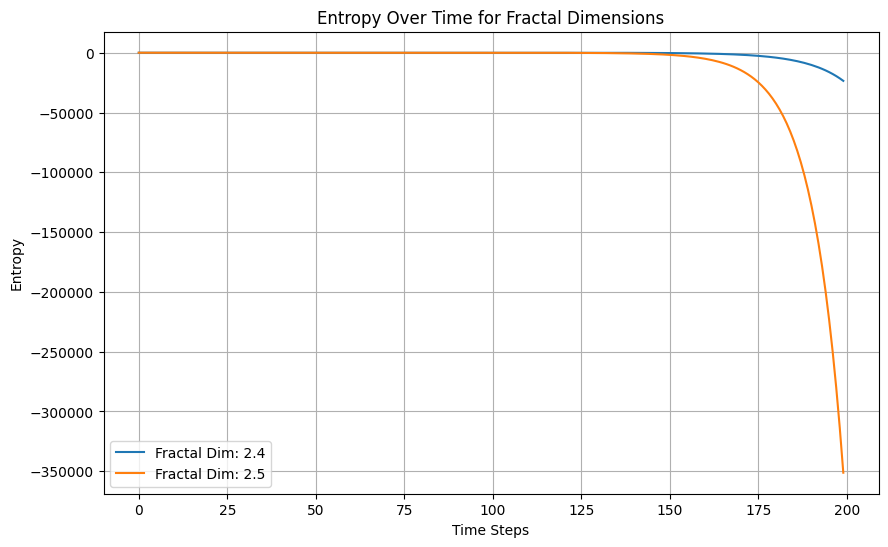

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.linalg import expm

# Constants
GRID_SIZE = 100  # Number of grid points
TIME_STEPS = 200  # Number of time steps
DELTA_X = 1.0  # Spatial resolution
DELTA_T = 0.01  # Time step
H_BAR = 1.0  # Reduced Planck's constant
MASS = 1.0  # Mass of the particle
FRACTAL_DIMENSIONS = [2.40, 2.50]  # Fractal dimensions to compare

# Laplacian operator for fractal geometry
def laplacian_operator(grid_size, fractal_dim):
    fractional_scaling = np.linspace(1, fractal_dim, grid_size) ** fractal_dim
    laplacian = diags([fractional_scaling, -2 * fractional_scaling, fractional_scaling], [0, -1, 1]).toarray()
    return laplacian / (DELTA_X**2)

# Initialize wavefunction
def initialize_wavefunction(grid_size):
    x = np.linspace(-grid_size // 2, grid_size // 2, grid_size)
    psi = np.exp(-(x**2) / 20.0) * np.exp(1j * 2.0 * np.pi * x / grid_size)
    return psi / np.linalg.norm(psi)

# Time evolution of the wavefunction
def evolve_wavefunction(psi, laplacian, time_steps, delta_t):
    hamiltonian = -H_BAR**2 / (2 * MASS) * laplacian
    evolution_operator = expm(-1j * hamiltonian * delta_t / H_BAR)
    psi_t = []

    for _ in range(time_steps):
        psi = evolution_operator @ psi
        psi_t.append(np.abs(psi)**2)

    return np.array(psi_t)

# Calculate entropy
def calculate_entropy(psi_t):
    entropies = []
    for prob_density in psi_t:
        entropy = -np.sum(prob_density * np.log(prob_density + 1e-12))  # Shannon entropy
        entropies.append(entropy)
    return entropies

# Plot entropy
def plot_entropy(entropies, fractal_dimensions):
    plt.figure(figsize=(10, 6))
    for entropy, fractal_dim in zip(entropies, fractal_dimensions):
        plt.plot(entropy, label=f"Fractal Dim: {fractal_dim}")
    plt.title("Entropy Over Time for Fractal Dimensions")
    plt.xlabel("Time Steps")
    plt.ylabel("Entropy")
    plt.legend()
    plt.grid()
    plt.show()

# Main experiment
def main():
    entropies = []
    for fractal_dim in FRACTAL_DIMENSIONS:
        print(f"Simulating for Fractal Dimension: {fractal_dim}...")
        laplacian = laplacian_operator(GRID_SIZE, fractal_dim)
        psi = initialize_wavefunction(GRID_SIZE)
        psi_t = evolve_wavefunction(psi, laplacian, TIME_STEPS, DELTA_T)
        entropy = calculate_entropy(psi_t)
        entropies.append(entropy)

    # Plot entropy comparison
    plot_entropy(entropies, FRACTAL_DIMENSIONS)

if __name__ == "__main__":
    main()


Simulating for Spherical Dimension: 1.0...
Simulating for Spherical Dimension: 10.0...


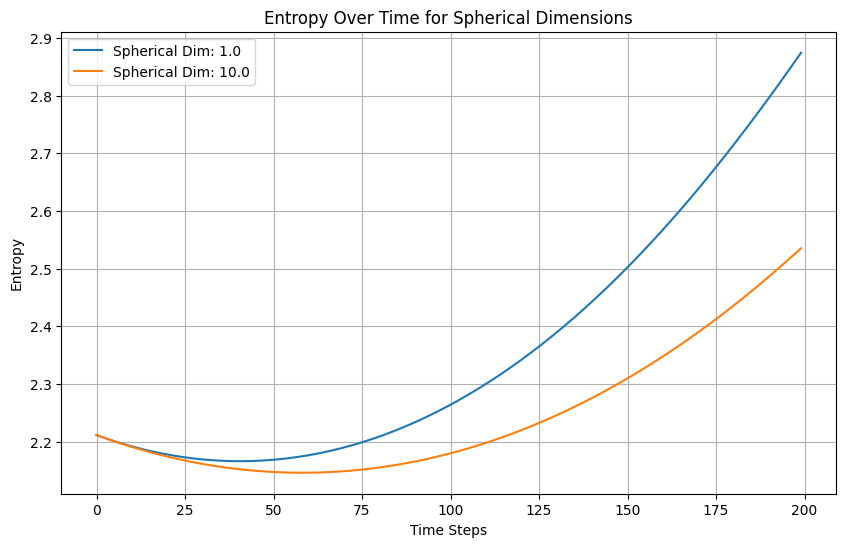

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.linalg import expm

# Constants
GRID_SIZE = 100  # Number of grid points
TIME_STEPS = 200  # Number of time steps
DELTA_X = 1.0  # Spatial resolution
DELTA_T = 0.01  # Time step
H_BAR = 1.0  # Reduced Planck's constant
MASS = 1.0  # Mass of the particle
SPHERICAL_DIMENSIONS = [1.00, 10.00]  # Dimensions to simulate spherical-like perturbations

# Laplacian operator for spherical geometry
def laplacian_operator(grid_size, spherical_dim):
    diagonal = np.ones(grid_size)
    off_diagonal = np.ones(grid_size - 1)
    laplacian = diags([diagonal, -2 * diagonal, diagonal], [0, -1, 1]).toarray()
    spherical_scaling = np.linspace(1, spherical_dim, grid_size)
    laplacian += np.diag(spherical_scaling)
    return laplacian / (DELTA_X**2)

# Initialize wavefunction
def initialize_wavefunction(grid_size):
    x = np.linspace(-grid_size // 2, grid_size // 2, grid_size)
    psi = np.exp(-(x**2) / 20.0) * np.exp(1j * 2.0 * np.pi * x / grid_size)
    return psi / np.linalg.norm(psi)

# Time evolution of the wavefunction
def evolve_wavefunction(psi, laplacian, time_steps, delta_t):
    hamiltonian = -H_BAR**2 / (2 * MASS) * laplacian
    evolution_operator = expm(-1j * hamiltonian * delta_t / H_BAR)
    psi_t = []

    for _ in range(time_steps):
        psi = evolution_operator @ psi
        psi_t.append(np.abs(psi)**2)

    return np.array(psi_t)

# Calculate entropy
def calculate_entropy(psi_t):
    entropies = []
    for prob_density in psi_t:
        entropy = -np.sum(prob_density * np.log(prob_density + 1e-12))  # Shannon entropy
        entropies.append(entropy)
    return entropies

# Plot entropy
def plot_entropy(entropies, spherical_dimensions):
    plt.figure(figsize=(10, 6))
    for entropy, spherical_dim in zip(entropies, spherical_dimensions):
        plt.plot(entropy, label=f"Spherical Dim: {spherical_dim}")
    plt.title("Entropy Over Time for Spherical Dimensions")
    plt.xlabel("Time Steps")
    plt.ylabel("Entropy")
    plt.legend()
    plt.grid()
    plt.show()

# Main experiment
def main():
    entropies = []
    for spherical_dim in SPHERICAL_DIMENSIONS:
        print(f"Simulating for Spherical Dimension: {spherical_dim}...")
        laplacian = laplacian_operator(GRID_SIZE, spherical_dim)
        psi = initialize_wavefunction(GRID_SIZE)
        psi_t = evolve_wavefunction(psi, laplacian, TIME_STEPS, DELTA_T)
        entropy = calculate_entropy(psi_t)
        entropies.append(entropy)

    # Plot entropy comparison
    plot_entropy(entropies, SPHERICAL_DIMENSIONS)

if __name__ == "__main__":
    main()

Simulating for Hybrid Ratio: 0.5...
Simulating for Hybrid Ratio: 0.7...
Simulating for Hybrid Ratio: 0.3...


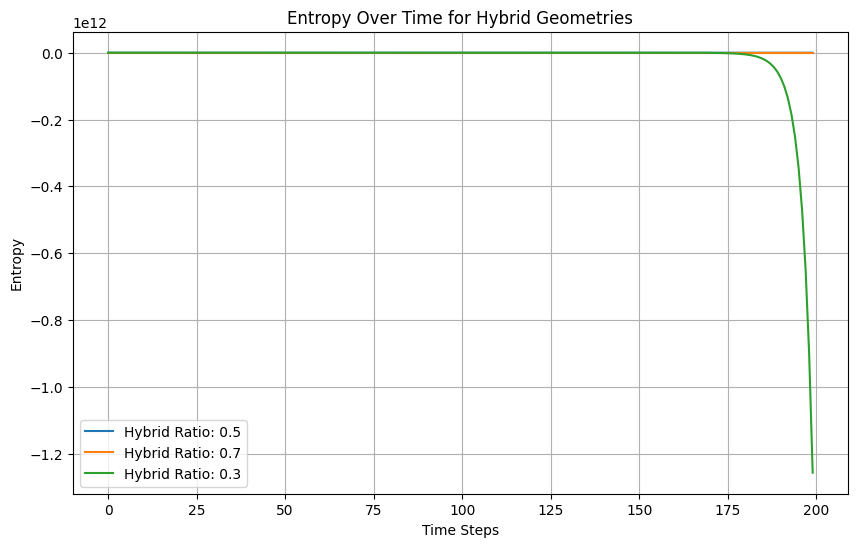

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.linalg import expm

# Constants
GRID_SIZE = 100  # Number of grid points
TIME_STEPS = 200  # Number of time steps
DELTA_X = 1.0  # Spatial resolution
DELTA_T = 0.01  # Time step
H_BAR = 1.0  # Reduced Planck's constant
MASS = 1.0  # Mass of the particle
HYBRID_RATIOS = [0.5, 0.7, 0.3]  # Ratios of spherical to fractal components
FRACTAL_DIM = 3.0  # Example fractal dimension for hybrid environment

# Hybrid Laplacian Operator
def hybrid_laplacian_operator(grid_size, hybrid_ratio, fractal_dim):
    spherical_scaling = np.linspace(1, 1 / grid_size, grid_size)
    fractal_scaling = np.linspace(1, fractal_dim, grid_size) ** fractal_dim
    hybrid_scaling = (
        hybrid_ratio * spherical_scaling + (1 - hybrid_ratio) * fractal_scaling
    )
    laplacian = diags([hybrid_scaling, -2 * hybrid_scaling, hybrid_scaling], [0, -1, 1]).toarray()
    return laplacian / (DELTA_X**2)

# Initialize wavefunction
def initialize_wavefunction(grid_size):
    x = np.linspace(-grid_size // 2, grid_size // 2, grid_size)
    psi = np.exp(-(x**2) / 20.0) * np.exp(1j * 2.0 * np.pi * x / grid_size)
    return psi / np.linalg.norm(psi)

# Time evolution of the wavefunction
def evolve_wavefunction(psi, laplacian, time_steps, delta_t):
    hamiltonian = -H_BAR**2 / (2 * MASS) * laplacian
    evolution_operator = expm(-1j * hamiltonian * delta_t / H_BAR)
    psi_t = []

    for _ in range(time_steps):
        psi = evolution_operator @ psi
        psi_t.append(np.abs(psi)**2)

    return np.array(psi_t)

# Calculate entropy
def calculate_entropy(psi_t):
    entropies = []
    for prob_density in psi_t:
        entropy = -np.sum(prob_density * np.log(prob_density + 1e-12))  # Shannon entropy
        entropies.append(entropy)
    return entropies

# Plot entropy
def plot_entropy(entropies, hybrid_ratios):
    plt.figure(figsize=(10, 6))
    for entropy, ratio in zip(entropies, hybrid_ratios):
        plt.plot(entropy, label=f"Hybrid Ratio: {ratio}")
    plt.title("Entropy Over Time for Hybrid Geometries")
    plt.xlabel("Time Steps")
    plt.ylabel("Entropy")
    plt.legend()
    plt.grid()
    plt.show()

# Main experiment
def main():
    entropies = []
    for hybrid_ratio in HYBRID_RATIOS:
        print(f"Simulating for Hybrid Ratio: {hybrid_ratio}...")
        laplacian = hybrid_laplacian_operator(GRID_SIZE, hybrid_ratio, FRACTAL_DIM)
        psi = initialize_wavefunction(GRID_SIZE)
        psi_t = evolve_wavefunction(psi, laplacian, TIME_STEPS, DELTA_T)
        entropy = calculate_entropy(psi_t)
        entropies.append(entropy)

    # Plot entropy comparison
    plot_entropy(entropies, HYBRID_RATIOS)

if __name__ == "__main__":
    main()

Training model with Fractal Dimension: 1.0


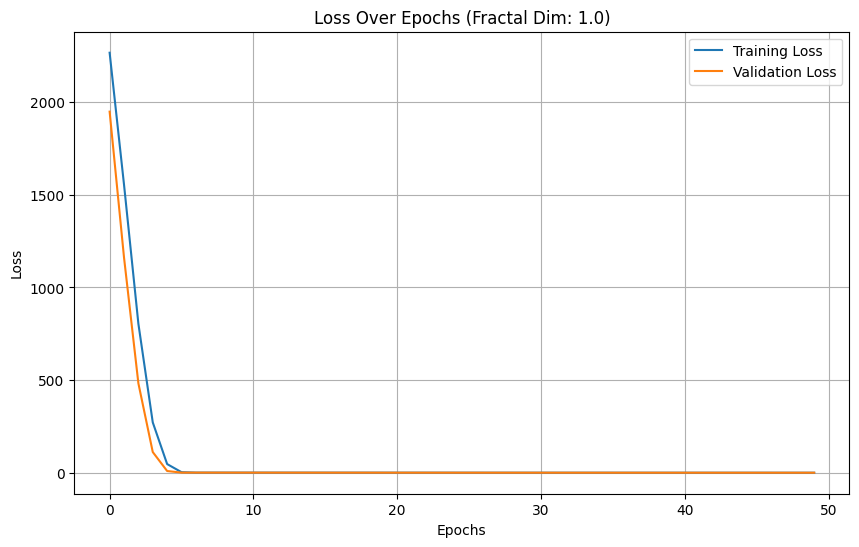

Training model with Fractal Dimension: 2.0


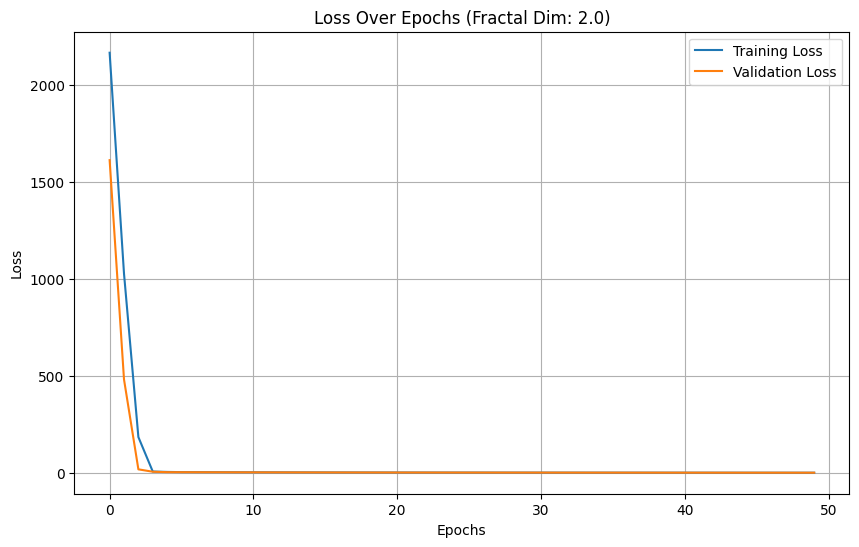

Training model with Fractal Dimension: 2.5


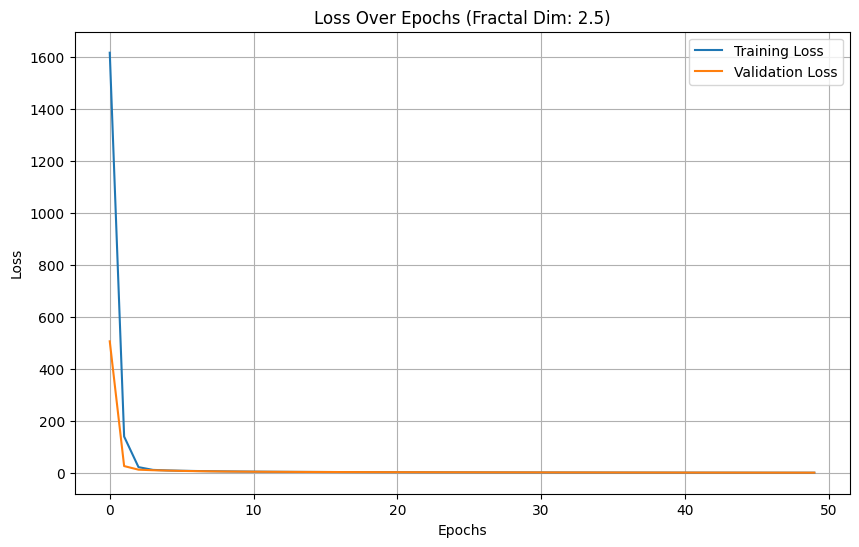

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Constants
GRID_SIZE = 100  # Number of grid points
TIME_STEPS = 200  # Number of time steps
FRACTAL_DIM = 3.0  # Default fractal dimension (can be adjusted)

# Generate a fractal-inspired weight matrix
def generate_fractal_weights(grid_size, fractal_dim):
    fractional_scaling = np.linspace(1, fractal_dim, grid_size) ** fractal_dim
    main_diag = fractional_scaling
    upper_diag = fractional_scaling[:-1]
    lower_diag = fractional_scaling[:-1]
    laplacian = (
        np.diag(main_diag) +
        np.diag(upper_diag, k=1) +
        np.diag(lower_diag, k=-1)
    )
    return laplacian - 2 * np.diag(main_diag)

# Custom fractal layer
class FractalLayer(layers.Layer):
    def __init__(self, fractal_dim=1.0):
        super(FractalLayer, self).__init__()
        self.fractal_dim = fractal_dim

    def build(self, input_shape):
        self.fractal_weights = self.add_weight(
            shape=(GRID_SIZE, GRID_SIZE),
            initializer=tf.constant_initializer(generate_fractal_weights(GRID_SIZE, self.fractal_dim)),
            trainable=False,
            name="fractal_weights"
        )

    def call(self, inputs):
        return tf.matmul(inputs, self.fractal_weights)

# Generate synthetic data
def generate_data(grid_size, num_samples):
    X = np.random.rand(num_samples, grid_size).astype(np.float32)
    y = np.sum(X, axis=1, keepdims=True).astype(np.float32)
    return X, y

# Build the neural network model
def build_model(fractal_dim):
    model = models.Sequential([
        layers.Input(shape=(GRID_SIZE,)),
        FractalLayer(fractal_dim=fractal_dim),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)  # Regression output
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

# Plot the training loss
def plot_loss(history, fractal_dim):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Loss Over Epochs (Fractal Dim: {fractal_dim})")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

# Main program
def main():
    fractal_dims = [1.0, 2.0, 2.5]  # Test different fractal dimensions
    num_samples = 1000  # Number of training samples
    epochs = 50  # Training epochs

    for fractal_dim in fractal_dims:
        print(f"Training model with Fractal Dimension: {fractal_dim}")
        X, y = generate_data(GRID_SIZE, num_samples)
        model = build_model(fractal_dim)
        history = model.fit(X, y, validation_split=0.2, epochs=epochs, verbose=0)
        plot_loss(history, fractal_dim)

if __name__ == "__main__":
    main()

Training model with Fractal Dimension: 1.0
Training model with Fractal Dimension: 5.0
Training model with Fractal Dimension: 50.0


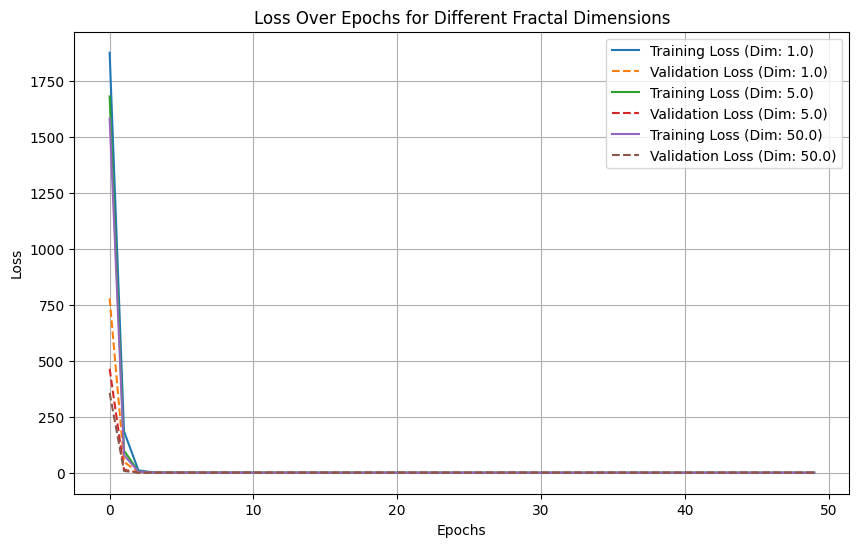

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers, optimizers

# Constants
GRID_SIZE = 100  # Number of grid points
EPOCHS = 50  # Number of epochs
BATCH_SIZE = 32  # Batch size for training
FRACTAL_DIMENSIONS = [1.0, 5.0, 50.0]  # Fractal dimensions to test

# Generate fractal weights
def generate_fractal_weights(grid_size, fractal_dim):
    fractional_scaling = np.linspace(1, fractal_dim, grid_size) ** fractal_dim
    main_diag = -2 * fractional_scaling
    upper_diag = fractional_scaling[:-1]
    lower_diag = fractional_scaling[:-1]
    laplacian = np.diag(main_diag) + np.diag(upper_diag, k=1) + np.diag(lower_diag, k=-1)
    return laplacian / (np.max(np.abs(laplacian)) + 1e-12)

# Custom fractal layer
class FractalLayer(layers.Layer):
    def __init__(self, fractal_dim, **kwargs):
        super(FractalLayer, self).__init__(**kwargs)
        self.fractal_dim = fractal_dim

    def build(self, input_shape):
        self.kernel = self.add_weight(
            shape=(input_shape[-1], input_shape[-1]),
            initializer=lambda shape, dtype: generate_fractal_weights(shape[0], self.fractal_dim),
            trainable=True,
        )

    def call(self, inputs):
        return inputs @ self.kernel

# Build model
def build_model(fractal_dim):
    model = models.Sequential([
        FractalLayer(fractal_dim=fractal_dim),
        layers.Dense(64, activation="relu"),
        layers.Dense(1),  # Regression output
    ])
    model.compile(optimizer=optimizers.Adam(), loss="mse", metrics=["mae"])
    return model

# Generate synthetic data
def generate_data(grid_size):
    x = np.random.rand(1000, grid_size)  # 1000 samples
    y = np.sum(x, axis=1, keepdims=True)  # Sum of each sample
    return x, y

# Train and evaluate model
def train_and_evaluate(fractal_dim):
    print(f"Training model with Fractal Dimension: {fractal_dim}")
    model = build_model(fractal_dim)
    x_train, y_train = generate_data(GRID_SIZE)
    history = model.fit(x_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.2, verbose=0)
    return history

# Plot loss
def plot_loss(histories, fractal_dimensions):
    plt.figure(figsize=(10, 6))
    for history, dim in zip(histories, fractal_dimensions):
        plt.plot(history.history['loss'], label=f"Training Loss (Dim: {dim})")
        plt.plot(history.history['val_loss'], label=f"Validation Loss (Dim: {dim})", linestyle="--")
    plt.title("Loss Over Epochs for Different Fractal Dimensions")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

# Main experiment
def main():
    histories = []
    for fractal_dim in FRACTAL_DIMENSIONS:
        history = train_and_evaluate(fractal_dim)
        histories.append(history)
    plot_loss(histories, FRACTAL_DIMENSIONS)

if __name__ == "__main__":
    main()
